# Análise de preços de imóveis com regressão linear

*House Sales in King County, USA*

**Trabalho desenvolvido para a disciplina de Modelagem Estatística.**

## 1. Pergunta e objetivos

Qual é a associação entre a área habitável e o preço de venda dos imóveis de King County, entre 2014 e 2015, e que proporção da variabilidade dos preços na amostra pode ser descrita por uma regressão linear simples?

A etapa inicial compreende a auditoria dos dados, a identificação de revendas e a análise das distribuições. Em seguida, são estimados e interpretados os coeficientes do **Modelo de Regressão Linear Simples (MRLS)**, que utiliza a área habitável como explicativa. A análise é posteriormente estendida ao **Modelo de Regressão Linear Múltipla (MRLM)**, com área, qualidade construtiva, banheiros, ano de construção e latitude, e a uma versão desse modelo com resposta em log.

A avaliação dos três modelos considera o ajuste na amostra e os diagnósticos dos resíduos. São examinadas também a multicolinearidade e as observações sinalizadas para investigação.

Cada observação representa **uma venda**; uma propriedade pode ter mais de uma venda registrada. A base é observacional, e as associações estimadas não demonstram causalidade. A avaliação preditiva fora da amostra e a inferência com covariância robusta ou agrupada por imóvel permanecem fora do escopo implementado.

**Fonte:** [House Sales in King County, USA — Kaggle](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction), identificador `harlfoxem/housesalesprediction`.

**Execução:** as células devem ser executadas na ordem em Jupyter ou Colab. Os arquivos `data/kc_house_data.csv`, `data/cambio.csv` e `data/cambio.json` permitem reproduzir a análise sem acesso à rede. Na ausência do CSV dos imóveis, o procedimento de leitura tenta obtê-lo no Kaggle. Caso os dados estejam em outro local, deve-se ajustar `CAMINHO`.

## 2. Variáveis, unidades e amostra

| Nome | Descrição | Unidade ou escala | Papel na análise |
| --- | --- | --- | --- |
| `price` | Preço original da venda | US$ nominais de 2014–2015 | Preservado; referência para conversão e comparação |
| `sqft_living` | Área habitável interna, distinta da área do terreno | Pés quadrados (sqft) | Preservada; origem da conversão da área |
| `preco` | `price × cambio` | R$ nominais na data da venda, sem correção pela inflação | Resposta do MRLS e do MRLM em reais |
| `area` | `sqft_living × 0.09290304` | m² | Explicativa dos três modelos principais |
| `cambio` | PTAX de venda de fechamento utilizada | R$/US$ | Conversão histórica do preço |
| `dia_cot` | Data efetiva da cotação utilizada | Data | Rastreabilidade da conversão |
| `grade` | Qualidade de construção e projeto, distinta da conservação (`condition`) | Escala ordinal de 1 a 13 | Descritiva e explicativa dos modelos múltiplos |
| `bathrooms` | Banheiros, incluindo contagens fracionárias | Contagem | Descritiva e explicativa dos modelos múltiplos |
| `yr_built` | Ano de construção | Ano | Descritiva e explicativa dos modelos múltiplos |
| `lat` | Latitude | Graus decimais | Descritiva e explicativa dos modelos múltiplos |
| `log_preco` | Logaritmo natural do preço numérico em reais, `ln(preco / 1 R$)` | Escala logarítmica | Resposta do MRLM com transformação logarítmica |

`id` identifica a propriedade; `date`, a data da venda; e `zipcode`, o código postal. Os códigos são mantidos como texto. As variáveis `sqft_lot`, `sqft_above`, `sqft_basement` e `sqft_living15` permanecem nas unidades originais: somente a área habitável utilizada nos modelos é convertida.

A auditoria determina o tamanho da amostra, o período efetivo e as exclusões. `dados_originais` preserva a base lida do CSV; `base_ajustada` reúne as vendas preparadas e convertidas. A denominação “ajustada” refere-se à preparação dos dados: os preços observados não são substituídos pelos preços estimados.

## 3. Bibliotecas e leitura da base

O ambiente padrão é o **Google Colab**. As importações são diretas. Caso alguma biblioteca esteja ausente, a instalação pode ser realizada pela linha comentada na célula seguinte. No **VS Code**, deve-se selecionar um kernel Python com as dependências do projeto. O trecho comentado permite instalá-las no próprio kernel.

A análise utiliza `pandas` para organizar os dados, `matplotlib` e `seaborn` para os gráficos e `statsmodels` para os modelos e diagnósticos. O nível de significância adotado é **5%**.

In [1]:
# Google Colab: se faltar alguma biblioteca, descomente a linha abaixo.
# %pip install numpy pandas matplotlib seaborn scipy statsmodels

# VS Code: selecione o kernel Python e instale as versões do projeto, se necessário.
# %pip install -r requirements.txt
# Após instalar ou reinstalar bibliotecas, reinicie o kernel e execute desde o início.

from pathlib import Path
from urllib.request import Request, urlopen
from urllib.parse import urlencode
from zipfile import ZipFile
from io import BytesIO
from datetime import timedelta
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import Markdown, display


def formatar_valor(valor, casas=2):
    return f'{valor:,.{casas}f}'.replace(',', '#').replace('.', ',').replace('#', '.')


def formatar_p(valor):
    return '< 0,001' if valor < 0.001 else formatar_valor(valor, 4)


ALFA = 0.05
SEMENTE = 42
PASTA = Path('resultados')
PASTA.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda valor:
              f'{valor:.5g}'.replace('.', ',') if 0 < abs(valor) < 1 else formatar_valor(valor, 2))

print('Bibliotecas importadas e ambiente configurado.')


Bibliotecas importadas e ambiente configurado.


### Funções de apoio

As funções de apoio centralizam a exportação de arquivos, o ajuste por **mínimos quadrados ordinários (MQO)** e a organização dos resultados estatísticos. As fórmulas, unidades e decisões de tratamento permanecem explícitas nas células de cada etapa.

In [2]:
def salvar_tabela(tabela, nome, indice=False):
    """Exporta uma tabela para resultados, preservando o índice quando solicitado."""
    tabela.to_csv(PASTA / nome, index=indice)


def salvar_grafico(figura, nome, recorte='tight'):
    """Salva e exibe uma figura com a resolução adotada no projeto."""
    figura.savefig(PASTA / nome, dpi=150, bbox_inches=recorte)
    plt.show()


def ajustar_modelo(base, formula):
    """Ajusta MQO clássico e exige todas as vendas, na ordem da base recebida."""
    modelo = smf.ols(formula, data=base, missing='raise').fit()
    linhas = pd.Index(modelo.model.data.row_labels)
    if int(modelo.nobs) != len(base) or not linhas.equals(base.index):
        raise ValueError('O modelo não utilizou exatamente as vendas da base recebida.')
    return modelo


def tabela_coef(modelo, unidades):
    """Organiza coeficientes, inferência clássica e unidades, sem arredondar estimativas."""
    intervalos = modelo.conf_int(alpha=ALFA)
    return pd.DataFrame({
        'coeficiente': modelo.params,
        'erro_padrao': modelo.bse,
        'estatistica_t': modelo.tvalues,
        'valor_p': modelo.pvalues.map(formatar_p),
        'ic_inferior': intervalos.iloc[:, 0],
        'ic_superior': intervalos.iloc[:, 1],
        'unidade': pd.Series({termo: unidades[termo] for termo in modelo.params.index})
    }).rename_axis('termo')


def resumir_medidas(modelo):
    """Reúne medidas do ajuste e identifica a covariância utilizada."""
    return {
        'vendas': int(modelo.nobs), 'parametros': len(modelo.params),
        'r2': modelo.rsquared, 'r2_ajustado': modelo.rsquared_adj,
        'sqr': modelo.ssr, 'erro_residual': np.sqrt(modelo.mse_resid),
        'estatistica_f': modelo.fvalue, 'valor_p_f': formatar_p(modelo.f_pvalue),
        'gl_modelo': int(modelo.df_model), 'gl_residuo': int(modelo.df_resid),
        'covariancia': modelo.cov_type
    }


def avaliar_residuos(modelo, nome):
    """Calcula JB e BP/Koenker nos resíduos e na matriz do modelo efetivo."""
    estatistica_jb, p_jb, assimetria, curtose = jarque_bera(modelo.resid)
    estatistica_bp, p_bp, _, _ = het_breuschpagan(modelo.resid, modelo.model.exog, robust=True)
    return {
        'modelo': nome, 'vendas': int(modelo.nobs),
        'escala_resposta': 'log do preço em R$' if nome == 'MRLM_log' else 'R$ nominal',
        'jarque_bera': estatistica_jb, 'valor_p_jb': formatar_p(p_jb),
        'breusch_pagan_koenker': estatistica_bp, 'valor_p_bp': formatar_p(p_bp),
        'assimetria_residual': assimetria, 'curtose_residual': curtose
    }


In [3]:
CAMINHO = Path('data/kc_house_data.csv')  # No Colab, altere se necessário.
URL = 'https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction'

if not CAMINHO.exists():
    try:
        pedido = Request(URL, headers={'User-Agent':'Mozilla/5.0'})
        with urlopen(pedido, timeout=90) as resposta:
            arquivo_zip = ZipFile(BytesIO(resposta.read()))
        nome_csv = next(n for n in arquivo_zip.namelist() if n.endswith('kc_house_data.csv'))
        CAMINHO.parent.mkdir(parents=True, exist_ok=True)
        CAMINHO.write_bytes(arquivo_zip.read(nome_csv))
    except Exception as erro:
        raise RuntimeError('Baixe kc_house_data.csv no Kaggle e ajuste CAMINHO para o arquivo local.') from erro

# ID e CEP são códigos: não devem ser interpretados como medidas numéricas.
dados_originais = pd.read_csv(CAMINHO, dtype={'id':'string', 'zipcode':'string'})
print('Quantidade de linhas e colunas:', dados_originais.shape)
display(dados_originais.head())
dados_originais.info()

Quantidade de linhas e colunas: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221.900,00",3,"1,00",1180,5650,"1,00",0,0,...,7,1180,0,1955,0,98178,"47,51","-122,26",1340,5650
1,6414100192,20141209T000000,"538.000,00",3,"2,25",2570,7242,"2,00",0,0,...,7,2170,400,1951,1991,98125,"47,72","-122,32",1690,7639
2,5631500400,20150225T000000,"180.000,00",2,"1,00",770,10000,"1,00",0,0,...,6,770,0,1933,0,98028,"47,74","-122,23",2720,8062
3,2487200875,20141209T000000,"604.000,00",4,"3,00",1960,5000,"1,00",0,0,...,7,1050,910,1965,0,98136,"47,52","-122,39",1360,5000
4,1954400510,20150218T000000,"510.000,00",3,"2,00",1680,8080,"1,00",0,0,...,8,1680,0,1987,0,98074,"47,62","-122,05",1800,7503


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  string 
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  string 
 17  lat            21613 non-null  float64
 18  long  

## 4. Auditoria e tratamento dos dados

A auditoria verifica ausências, datas inválidas, duplicatas exatas e a validade do preço e da área habitável. São excluídas as cópias adicionais de linhas integralmente idênticas e as vendas sem os campos essenciais válidos. Cada exclusão registra o motivo e a linha de origem.

A repetição isolada de `id` não caracteriza uma duplicata exata. As revendas e os valores extremos de preço e área são preservados quando atendem às regras da auditoria; a análise por propriedade é apresentada na seção 6. Valores que requerem verificação nas demais características são sinalizados para conferência, sem correções presumidas.

In [4]:
variaveis_origem = ['price', 'sqft_living', 'grade', 'bathrooms', 'yr_built', 'lat']
auditoria = pd.DataFrame({
    'tipo': dados_originais.dtypes.astype(str),
    'ausentes': dados_originais.isna().sum(),
    'valores_distintos': dados_originais.nunique()
})
display(auditoria)

duplicatas = dados_originais.duplicated(keep='first')
print('Linhas completamente duplicadas:', int(duplicatas.sum()))

dados = dados_originais.copy()
dados['linha_csv'] = dados.index + 2
dados['date'] = pd.to_datetime(dados['date'], format='%Y%m%dT%H%M%S', errors='coerce')
colunas_numericas = dados_originais.columns.difference(['id', 'date', 'zipcode'])
for coluna in colunas_numericas:
    dados[coluna] = pd.to_numeric(dados[coluna], errors='coerce').replace([np.inf, -np.inf], np.nan)

problemas = pd.DataFrame(index=dados.index)
problemas['duplicata_exata'] = duplicatas
problemas['essencial_ausente'] = dados[['id', 'date', 'price', 'sqft_living']].isna().any(axis=1)
problemas['id_vazio'] = dados['id'].str.strip().eq('').fillna(False)
problemas['preco_ou_area_nao_positivo'] = (dados['price'] <= 0) | (dados['sqft_living'] <= 0)
mascara_invalidos = problemas.any(axis=1)
motivos = problemas.apply(lambda linha: ', '.join(linha.index[linha]), axis=1)
excluidos = dados.loc[mascara_invalidos].copy()
excluidos['motivos'] = motivos.loc[mascara_invalidos]
dados = dados.loc[~mascara_invalidos].copy()
salvar_tabela(excluidos, 'linhas_excluidas.csv')

if dados.empty:
    raise ValueError('A auditoria não encontrou vendas válidas para a análise.')
print('Vendas excluídas pela auditoria:', len(excluidos))
print('Vendas mantidas:', len(dados))
print('Imóveis distintos:', dados['id'].nunique())
print('Período das vendas:', dados['date'].min().date(), 'a', dados['date'].max().date())

,tipo,ausentes,valores_distintos
id,string,0,21436
date,object,0,372
price,float64,0,4028
bedrooms,int64,0,13
bathrooms,float64,0,30
sqft_living,int64,0,1038
sqft_lot,int64,0,9782
floors,float64,0,6
waterfront,int64,0,2
view,int64,0,5


Linhas completamente duplicadas: 0


Vendas excluídas pela auditoria: 0
Vendas mantidas: 21613
Imóveis distintos: 21436
Período das vendas: 2014-05-02 a 2015-05-27


In [5]:
# Sinalizar situações cadastrais sem alterar ou excluir por suposição.
suspeita = (
    (dados['bedrooms'] >= 20)
    | (dados['bathrooms'] <= 0)
    | (dados['yr_built'] > dados['date'].dt.year)
    | (dados['yr_built'] <= 0)
    | ~dados['grade'].between(1, 13)
    | ~dados['lat'].between(-90, 90)
    | dados[['grade', 'bathrooms', 'yr_built', 'lat']].isna().any(axis=1)
)
suspeitos = dados.loc[suspeita, ['linha_csv', 'id', 'date', 'price', 'bedrooms', 'bathrooms', 'grade', 'yr_built', 'lat']]
print('Registros sinalizados para conferência:', len(suspeitos))
display(suspeitos.head(15))
print('Identidade sqft_living = sqft_above + sqft_basement:',
      bool((dados['sqft_living'] == dados['sqft_above'] + dados['sqft_basement']).all()))

Registros sinalizados para conferência: 23


,linha_csv,id,date,price,bedrooms,bathrooms,grade,yr_built,lat
875,877,6306400140,2014-06-12,"1.095.000,00",0,"0,00",7,1990,"47,64"
1149,1151,3421079032,2015-02-17,"75.000,00",1,"0,00",3,1966,"47,26"
1763,1765,1832100030,2014-06-25,"597.326,00",4,"4,00",10,2015,"47,58"
2687,2689,3076500830,2014-10-29,"385.195,00",1,"1,00",6,2015,"47,58"
3119,3121,3918400017,2015-02-05,"380.000,00",0,"0,00",8,2006,"47,71"
5832,5834,5702500050,2014-11-04,"280.000,00",1,"0,00",3,1950,"47,53"
6994,6996,2954400190,2014-06-24,"1.295.650,00",0,"0,00",12,1990,"47,66"
7526,7528,9520900210,2014-12-31,"614.285,00",5,"2,75",8,2015,"47,77"
8039,8041,1250200495,2014-06-24,"455.000,00",2,"1,50",8,2015,"47,60"
9773,9775,3374500520,2015-04-29,"355.000,00",0,"0,00",8,1990,"47,41"


Identidade sqft_living = sqft_above + sqft_basement: True


**Decisões de tratamento:** Contagens fracionárias de banheiros são preservadas. Registros com 33 quartos ou zero banheiros requerem conferência cadastral e permanecem sem correção na ausência de evidência.

`id` e `zipcode` são identificadores e não são utilizados como preditores numéricos. A ausência de cotação deve ser resolvida antes da conversão e da regressão; essa condição não justifica a exclusão de uma venda válida. Nesta etapa, não há padronização nem transformação logarítmica automática.

## 5. Conversão para m² e reais nominais

A área habitável é convertida pelo fator exato **1 sqft = 0,09290304 m²**. O preço é convertido pela **PTAX de venda de fechamento na data da venda**, consultada no [Banco Central](https://dadosabertos.bcb.gov.br/pt_PT/dataset/dolar-americano-usd-todos-os-boletins-diarios). Na ausência de cotação na data da venda, utiliza-se a última cotação anterior disponível. A data efetiva é registrada em `dia_cot`.

O cache `data/cambio.csv` armazena as cotações, e `data/cambio.json` registra a fonte, a série e o período consultado. Uma execução dentro desse período utiliza o cache local. A primeira consulta ou a ampliação do período exige acesso à rede.

Os preços convertidos são **nominais, sem correção pela inflação**. A conversão fixa da área altera a unidade da inclinação, preservando o conteúdo do ajuste. A conversão histórica do preço aplica cotações diferentes entre vendas e incorpora variação cambial à resposta. Para examinar essa diferença, a análise apresenta uma referência em dólares com as mesmas observações.

In [6]:
CAMBIO_CSV = Path('data/cambio.csv')
CAMBIO_META = CAMBIO_CSV.with_suffix('.json')
PTAX = 'https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/'
FATOR_AREA = 0.09290304

def validar_cambio(cotacoes):
    if not {'dia_cot', 'cambio'}.issubset(cotacoes.columns):
        raise ValueError('As cotações precisam das colunas dia_cot e cambio.')
    cotacoes = cotacoes[['dia_cot', 'cambio']].copy()
    cotacoes['dia_cot'] = pd.to_datetime(cotacoes['dia_cot'], errors='coerce').dt.normalize()
    cotacoes['cambio'] = pd.to_numeric(cotacoes['cambio'], errors='coerce')
    if cotacoes.empty or cotacoes['dia_cot'].isna().any():
        raise ValueError('O cache de câmbio está vazio ou contém datas inválidas.')
    if not np.isfinite(cotacoes['cambio']).all() or (cotacoes['cambio'] <= 0).any():
        raise ValueError('A cotação precisa ser numérica, finita e positiva.')
    if cotacoes['dia_cot'].duplicated().any():
        raise ValueError('É necessária uma única cotação de fechamento por dia.')
    return cotacoes.sort_values('dia_cot').reset_index(drop=True)

def ler_cambio(data_ini, data_fim):
    data_ini, data_fim = pd.Timestamp(data_ini).normalize(), pd.Timestamp(data_fim).normalize()
    if CAMBIO_CSV.exists():
        cotacoes = validar_cambio(pd.read_csv(CAMBIO_CSV))
        if not CAMBIO_META.exists():
            raise ValueError('O cache de câmbio precisa do arquivo de metadados cambio.json.')
        metadados = json.loads(CAMBIO_META.read_text(encoding='utf-8'))
        if not isinstance(metadados, dict) or not {'inicio', 'fim'}.issubset(metadados):
            raise ValueError('Os metadados precisam informar o período consultado.')
        inicio_cache = pd.to_datetime(metadados['inicio'], errors='coerce')
        fim_cache = pd.to_datetime(metadados['fim'], errors='coerce')
        if pd.isna(inicio_cache) or pd.isna(fim_cache) or inicio_cache > fim_cache:
            raise ValueError('O período informado nos metadados é inválido.')
        if (metadados.get('serie') != 'cotacaoVenda'
                or metadados.get('boletim') != 'fechamento'
                or metadados.get('linhas') != len(cotacoes)
                or cotacoes['dia_cot'].min() < inicio_cache
                or cotacoes['dia_cot'].max() > fim_cache):
            raise ValueError('As cotações e os metadados do cache são incompatíveis.')
        if inicio_cache <= data_ini and data_fim <= fim_cache:
            return cotacoes

    inicio_consulta = pd.Timestamp(data_ini.date() - timedelta(days=7))
    parametros = {
        '@dataInicial': f"'{inicio_consulta.strftime('%m-%d-%Y')}'",
        '@dataFinalCotacao': f"'{data_fim.strftime('%m-%d-%Y')}'",
        '$format': 'json', '$orderby': 'dataHoraCotacao', '$top': '10000'
    }
    endereco = PTAX + 'CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?' + urlencode(parametros)
    try:
        pedido = Request(endereco, headers={'User-Agent': 'AnaliseHouseSales/1.0', 'Accept': 'application/json'})
        with urlopen(pedido, timeout=40) as resposta:
            retorno = json.load(resposta)
    except (OSError, ValueError) as erro:
        raise RuntimeError('Não foi possível consultar a PTAX. Confira a rede ou o cache local antes de ajustar o modelo.') from erro
    if retorno.get('@odata.nextLink'):
        raise ValueError('A consulta PTAX excedeu uma página; reduza o período antes de continuar.')
    cotacoes = pd.DataFrame(retorno.get('value', []))
    if not {'dataHoraCotacao', 'cotacaoVenda'}.issubset(cotacoes.columns):
        raise ValueError('A consulta não retornou as cotações de venda esperadas.')
    cotacoes = validar_cambio(cotacoes.rename(columns={'dataHoraCotacao': 'dia_cot', 'cotacaoVenda': 'cambio'}))
    if cotacoes['dia_cot'].min() > data_ini or cotacoes['dia_cot'].max() > data_fim:
        raise ValueError('A consulta PTAX não cobre corretamente o início das vendas.')
    metadados = {
        'fonte': endereco, 'serie': 'cotacaoVenda', 'boletim': 'fechamento',
        'inicio': inicio_consulta.date().isoformat(), 'fim': data_fim.date().isoformat(),
        'linhas': len(cotacoes)
    }
    CAMBIO_CSV.parent.mkdir(parents=True, exist_ok=True)
    cotacoes.to_csv(CAMBIO_CSV, index=False, date_format='%Y-%m-%d')
    CAMBIO_META.write_text(json.dumps(metadados, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
    return cotacoes

def converter(base, cotacoes):
    cotacoes = validar_cambio(cotacoes)
    campos = {'id', 'date', 'price', 'sqft_living', 'linha_csv'}
    if not campos.issubset(base.columns) or base.empty:
        raise ValueError('A conversão precisa de vendas auditadas e suas linhas de origem.')
    if base['date'].isna().any() or not base['linha_csv'].is_unique:
        raise ValueError('Confira as datas e a identificação das linhas antes da conversão.')
    valores = base[['price', 'sqft_living']].to_numpy(dtype=float)
    if not np.isfinite(valores).all() or (valores <= 0).any():
        raise ValueError('Preço e área originais precisam ser finitos e positivos.')
    vendas = base.assign(dia_venda=base['date'].dt.normalize())
    resultado = pd.merge_asof(
        vendas.sort_values(['dia_venda', 'linha_csv']), cotacoes,
        left_on='dia_venda', right_on='dia_cot',
        direction='backward', allow_exact_matches=True
    ).sort_values('linha_csv').reset_index(drop=True)
    if resultado['cambio'].isna().any():
        raise ValueError('Há venda sem cotação anterior disponível; complete o cache antes de continuar.')
    if (resultado['dia_cot'] > resultado['dia_venda']).any() or len(resultado) != len(base):
        raise ValueError('A associação de cotações alterou as vendas ou usou uma data futura.')
    resultado['area'] = resultado['sqft_living'] * FATOR_AREA
    resultado['preco'] = resultado['price'] * resultado['cambio']
    valores_convertidos = resultado[['area', 'preco']].to_numpy()
    if not np.isfinite(valores_convertidos).all() or (valores_convertidos <= 0).any():
        raise ValueError('A conversão precisa produzir valores finitos e positivos.')
    return resultado

cotacoes = ler_cambio(dados['date'].min(), dados['date'].max())
base_ajustada = converter(dados, cotacoes)
atraso_cotacao = (base_ajustada['dia_venda'] - base_ajustada['dia_cot']).dt.days
print('Vendas convertidas:', len(base_ajustada))
print('Vendas que utilizaram cotação anterior:', int((atraso_cotacao > 0).sum()))
print('Maior intervalo até a cotação utilizada:', int(atraso_cotacao.max()), 'dias')
print('PTAX aplicada: de', formatar_valor(base_ajustada['cambio'].min(), 4),
      'a', formatar_valor(base_ajustada['cambio'].max(), 4), 'R$/US$')
display(base_ajustada[['linha_csv', 'id', 'date', 'price', 'dia_cot', 'cambio', 'preco', 'sqft_living', 'area']].head())

Vendas convertidas: 21613
Vendas que utilizaram cotação anterior: 964
Maior intervalo até a cotação utilizada: 4 dias
PTAX aplicada: de 2,1975 a 3,2683 R$/US$


,linha_csv,id,date,price,dia_cot,cambio,preco,sqft_living,area
0,2,7129300520,2014-10-13,"221.900,00",2014-10-13,"2,39","530.851,37",1180,"109,63"
1,3,6414100192,2014-12-09,"538.000,00",2014-12-09,"2,60","1.399.660,80",2570,"238,76"
2,4,5631500400,2015-02-25,"180.000,00",2015-02-25,"2,86","515.628,00",770,"71,54"
3,5,2487200875,2014-12-09,"604.000,00",2014-12-09,"2,60","1.571.366,40",1960,"182,09"
4,6,1954400510,2015-02-18,"510.000,00",2015-02-18,"2,84","1.449.930,00",1680,"156,08"


## 6. Propriedades com o mesmo ID

As vendas são agrupadas por propriedade e ordenadas por data. Para cada ID repetido, a análise examina o número de transações, o intervalo entre a primeira e a última venda, os preços originais e convertidos e as mudanças de área, qualidade construtiva, banheiros, ano de construção e localização. Também são identificadas transações realizadas no mesmo dia.

In [7]:
def analisar_ids(base):
    repetidas = base.loc[base['id'].duplicated(keep=False)].sort_values(['id', 'date', 'linha_csv']).copy()
    colunas = ['id', 'vendas', 'primeira_venda', 'ultima_venda', 'dias_entre',
               'preco_usd_inicial', 'preco_usd_final', 'preco_inicial', 'preco_final',
               'variacao_usd_pct', 'variacao_reais_pct', 'mesmo_dia',
               'mudanca_area', 'mudanca_grade', 'mudanca_banheiros', 'mudanca_ano', 'mudanca_localizacao']
    registros = []
    for codigo, grupo in repetidas.groupby('id', sort=True):
        primeira, ultima = grupo.iloc[0], grupo.iloc[-1]
        registros.append({
            'id': codigo, 'vendas': len(grupo),
            'primeira_venda': primeira['date'], 'ultima_venda': ultima['date'],
            'dias_entre': (ultima['date'] - primeira['date']).days,
            'preco_usd_inicial': primeira['price'], 'preco_usd_final': ultima['price'],
            'preco_inicial': primeira['preco'], 'preco_final': ultima['preco'],
            'variacao_usd_pct': 100 * (ultima['price'] / primeira['price'] - 1),
            'variacao_reais_pct': 100 * (ultima['preco'] / primeira['preco'] - 1),
            'mesmo_dia': grupo['date'].dt.normalize().duplicated(keep=False).any(),
            'mudanca_area': grupo['sqft_living'].nunique(dropna=False) > 1,
            'mudanca_grade': grupo['grade'].nunique(dropna=False) > 1,
            'mudanca_banheiros': grupo['bathrooms'].nunique(dropna=False) > 1,
            'mudanca_ano': grupo['yr_built'].nunique(dropna=False) > 1,
            'mudanca_localizacao': any(grupo[coluna].nunique(dropna=False) > 1 for coluna in ['lat', 'long', 'zipcode'])
        })
    return pd.DataFrame(registros, columns=colunas), repetidas

analise_ids, vendas_repetidas = analisar_ids(base_ajustada)
print('Propriedades com mais de uma venda:', len(analise_ids))
print('Vendas dessas propriedades:', len(vendas_repetidas))
print('Ocorrências adicionais além da primeira venda:', len(vendas_repetidas) - len(analise_ids))
print('IDs com vendas no mesmo dia:', int(analise_ids['mesmo_dia'].sum()))
if not analise_ids.empty:
    display(analise_ids[['id', 'vendas', 'dias_entre', 'variacao_usd_pct', 'variacao_reais_pct']].head(10))
    colunas_mudanca = [coluna for coluna in analise_ids if coluna.startswith('mudanca_')]
    display(analise_ids[colunas_mudanca].sum().rename('ids_com_mudanca').to_frame())
    display(vendas_repetidas[['linha_csv', 'id', 'date', 'price', 'preco', 'area']].head(12))
salvar_tabela(analise_ids, 'analise_ids.csv')
salvar_tabela(vendas_repetidas, 'vendas_repetidas.csv')

Propriedades com mais de uma venda: 176
Vendas dessas propriedades: 353
Ocorrências adicionais além da primeira venda: 177
IDs com vendas no mesmo dia: 0


,id,vendas,dias_entre,variacao_usd_pct,variacao_reais_pct
0,0001000102,2,218,"7,14","38,50"
1,0007200179,2,190,"16,67","40,10"
2,0109200390,2,61,"2,04","11,11"
3,0123039336,2,180,"65,47","92,30"
4,0251300110,2,167,"59,11","84,01"
5,0302000375,2,265,"47,84","98,09"
6,0324000530,2,258,"127,79","227,03"
7,0526059224,2,136,"80,77","107,97"
8,0641900050,2,171,"49,24","82,63"
9,0643300040,2,129,"49,59","91,56"


,ids_com_mudanca
mudanca_area,0
mudanca_grade,0
mudanca_banheiros,0
mudanca_ano,0
mudanca_localizacao,0


,linha_csv,id,date,price,preco,area
2496,2498,0001000102,2014-09-16,"280.000,00","653.828,00","222,97"
2497,2499,0001000102,2015-04-22,"300.000,00","905.580,00","222,97"
16814,16816,0007200179,2014-10-16,"150.000,00","371.550,00","78,04"
16815,16817,0007200179,2015-04-24,"175.000,00","520.537,50","78,04"
11433,11435,0109200390,2014-08-20,"245.000,00","552.475,00","137,50"
11434,11436,0109200390,2014-10-20,"250.000,00","613.850,00","137,50"
12417,12419,0123039336,2014-06-11,"148.000,00","330.143,60","57,60"
12418,12420,0123039336,2014-12-08,"244.900,00","634.854,27","57,60"
7792,7794,0251300110,2014-07-31,"225.000,00","510.165,00","233,19"
7793,7795,0251300110,2015-01-14,"358.000,00","938.747,60","233,19"


**Interpretação das revendas:** a variação entre o primeiro e o último preço é descritiva. Essa medida não representa uma taxa anualizada de valorização e não controla reformas, características do imóvel, inflação ou variação cambial entre as datas.

Diferenças nos atributos podem refletir alterações reais, divergências cadastrais ou inconsistências; a base não permite determinar a causa automaticamente. Vendas do mesmo imóvel no mesmo dia, com informações diferentes, são sinalizadas para conferência e preservadas.

A ocorrência de múltiplas vendas da mesma propriedade requer atenção à possível dependência entre os erros na inferência.

## 7. Análise descritiva

A análise examina média, mediana, quartis, dispersão, extremos e assimetria. Preço e área são apresentados em **R$ nominais** e **m²**.

Qualidade construtiva, banheiros, ano de construção e latitude complementam a descrição da amostra e integram os modelos múltiplos. O MRLS utiliza somente a área habitável.

In [8]:
variaveis = ['preco', 'area', 'grade', 'bathrooms', 'yr_built', 'lat']
unidades = {'preco': 'R$ nominal', 'area': 'm²', 'grade': 'escala 1–13',
            'bathrooms': 'contagem', 'yr_built': 'ano', 'lat': 'graus decimais'}
descritiva = base_ajustada[variaveis].describe().T.rename(columns={
    'count': 'n', 'mean': 'média', 'std': 'desvio_padrão', 'min': 'mínimo',
    '25%': 'Q1', '50%': 'mediana', '75%': 'Q3', 'max': 'máximo'
})
descritiva.insert(0, 'unidade', pd.Series(unidades))
descritiva['assimetria'] = base_ajustada[variaveis].skew()
display(descritiva)
print('-'*62)
print('Resumo estatístico das variáveis de interesse:\n')
print('Preço médio: R$', formatar_valor(base_ajustada['preco'].mean()))
print('Preço mediano: R$', formatar_valor(base_ajustada['preco'].median()))
print('Área média:', formatar_valor(base_ajustada['area'].mean()), 'm²')
print('Área mediana:', formatar_valor(base_ajustada['area'].median()), 'm²')
print('Assimetria do preço:', formatar_valor(base_ajustada['preco'].skew(), 3))

grupos_area = base_ajustada.assign(faixa_area=pd.qcut(base_ajustada['area'], 4, duplicates='drop'))
resumo_area = grupos_area.groupby('faixa_area', observed=True).agg(
    vendas=('preco', 'size'), area_min=('area', 'min'), area_max=('area', 'max'),
    preco_mediano=('preco', 'median')
)
print('Preço mediano por faixa de área (R$ nominais):')
display(resumo_area)
salvar_tabela(descritiva, 'analise_descritiva.csv', indice=True)

,unidade,n,média,desvio_padrão,mínimo,Q1,mediana,Q3,máximo,assimetria
preco,R$ nominal,"21.613,00","1.377.071,59","960.387,17","174.111,60","806.874,75","1.143.914,00","1.650.718,00","18.420.710,00","3,91"
area,m²,"21.613,00","193,23","85,33","26,94","132,57","177,44","236,90","1.257,91","1,47"
grade,escala 1–13,"21.613,00","7,66","1,18","1,00","7,00","7,00","8,00","13,00","0,7711"
bathrooms,contagem,"21.613,00","2,11","0,77016","0,00","1,75","2,25","2,50","8,00","0,51111"
yr_built,ano,"21.613,00","1.971,01","29,37","1.900,00","1.951,00","1.975,00","1.997,00","2.015,00","-0,46981"
lat,graus decimais,"21.613,00","47,56","0,13856","47,16","47,47","47,57","47,68","47,78","-0,48527"


--------------------------------------------------------------
Resumo estatístico das variáveis de interesse:

Preço médio: R$ 1.377.071,59
Preço mediano: R$ 1.143.914,00
Área média: 193,23 m²
Área mediana: 177,44 m²
Assimetria do preço: 3,908
Preço mediano por faixa de área (R$ nominais):


,vendas,area_min,area_max,preco_mediano
faixa_area,,,,
"(26.941, 132.573]",5404,"26,94","132,57","804.172,77"
"(132.573, 177.445]",5416,"132,85","177,44","993.176,25"
"(177.445, 236.903]",5434,"177,63","236,90","1.219.949,12"
"(236.903, 1257.907]",5359,"237,37","1.257,91","1.876.238,00"


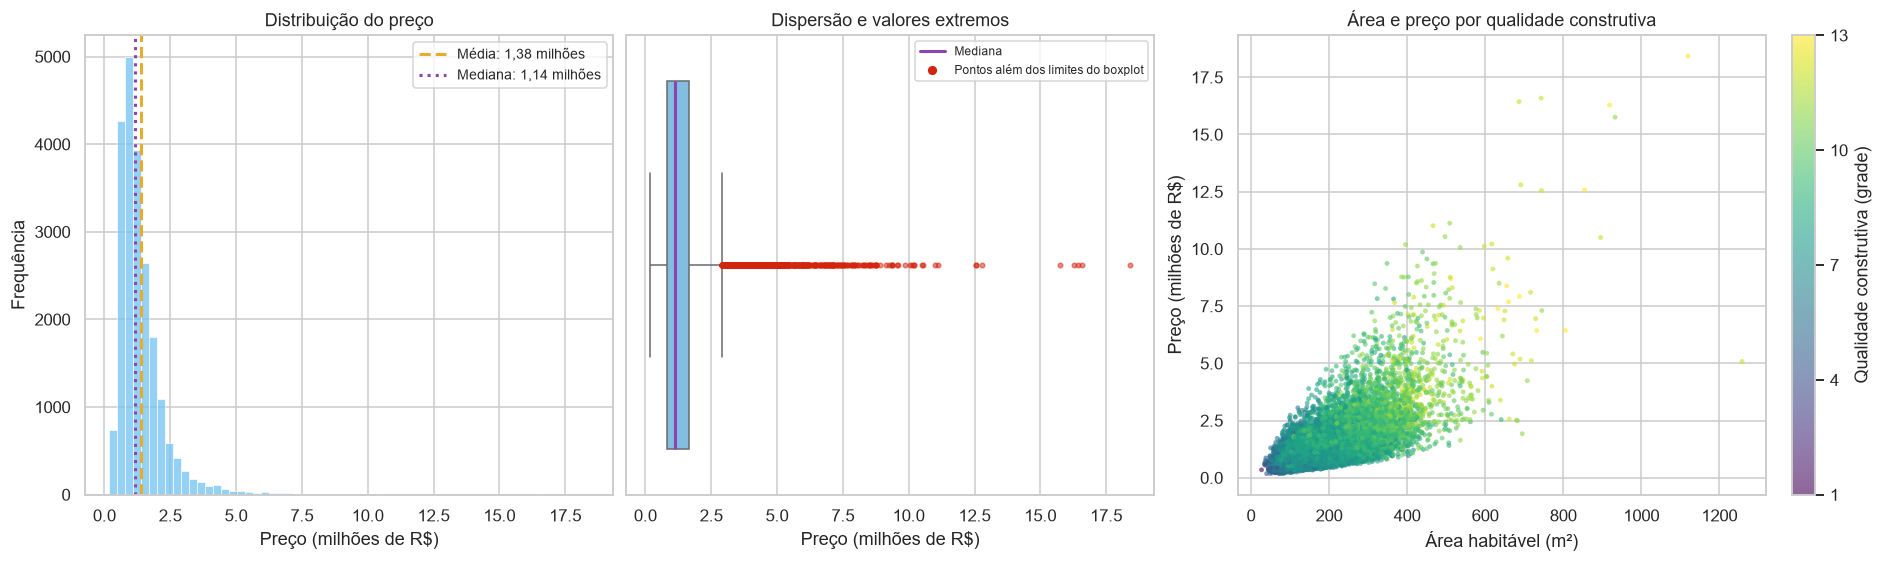

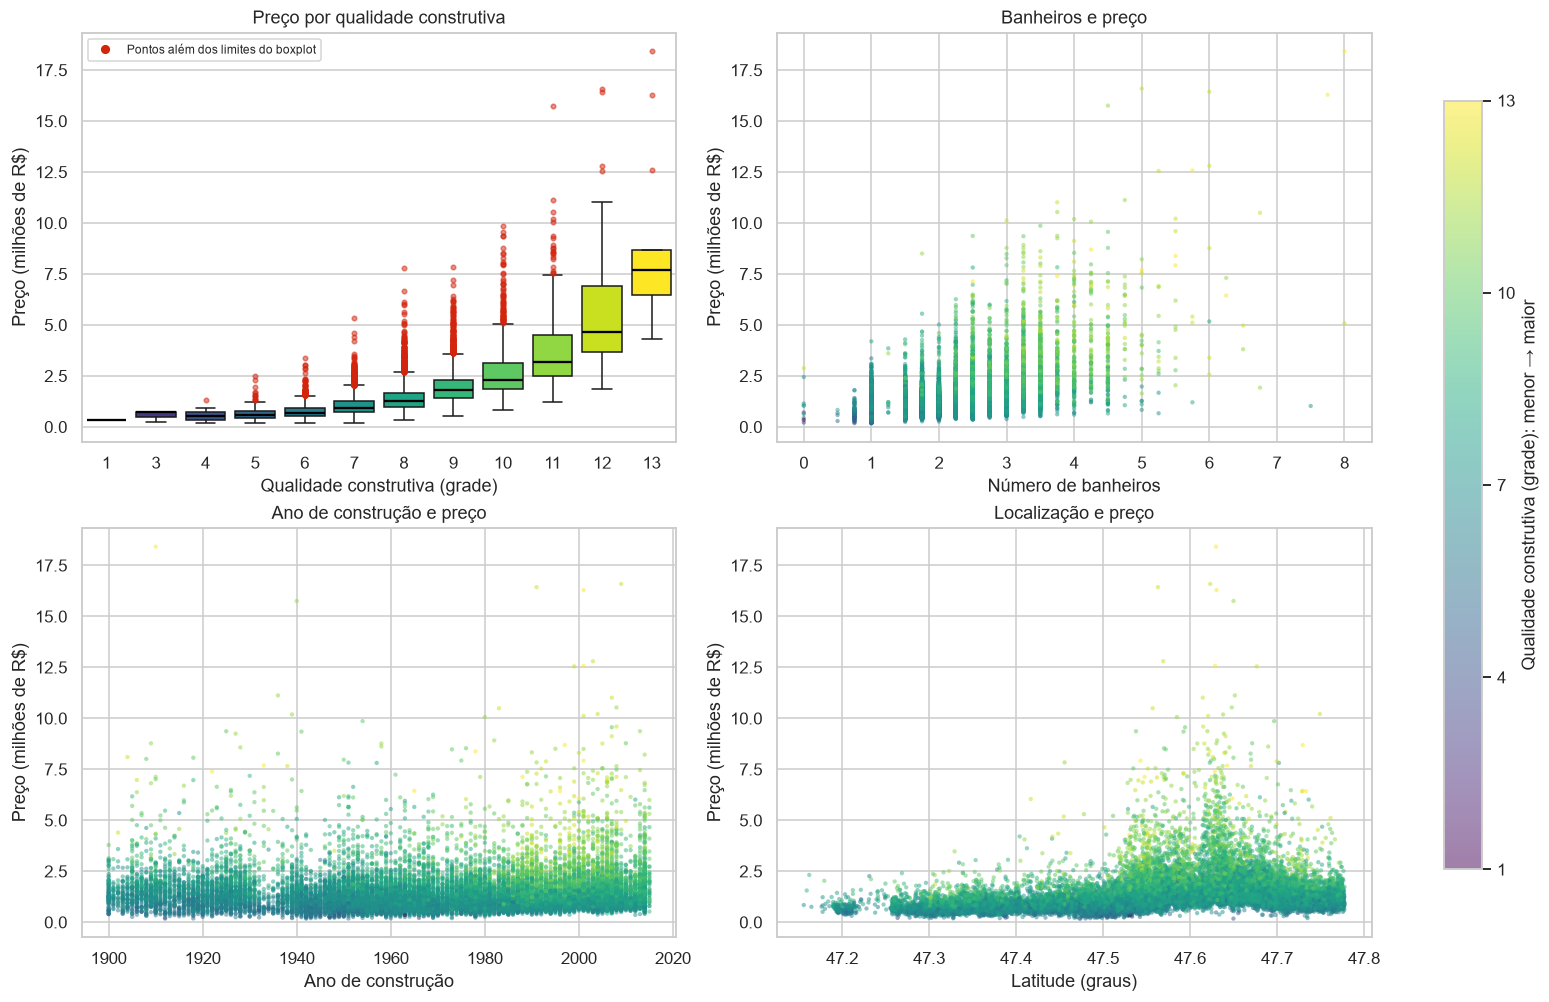

In [9]:
# Cores com significados definidos.
AZUL = "#71C2F1"
LARANJA = "#E7AC2D"
ROXO = '#8E44AD'
VERMELHO = "#D3250E"

preco_milhoes = base_ajustada['preco'] / 1e6

# A mesma qualidade construtiva terá a mesma cor em todos os gráficos.
mapa_cores = plt.get_cmap('viridis')
normalizacao = Normalize(vmin=1, vmax=13)

grades = sorted(base_ajustada['grade'].unique())
paleta_grade = {
    grade: mapa_cores(normalizacao(grade))
    for grade in grades
}

def dispersao_grade(eixo, base, coluna, tamanho=8, opacidade=0.5):
    """Plota preço em milhões de reais com a escala de cores comum de grade."""
    return eixo.scatter(
        base[coluna], base['preco'] / 1e6, c=base['grade'],
        cmap=mapa_cores, norm=normalizacao, s=tamanho,
        alpha=opacidade, edgecolors='none'
    )


# Aparência dos pontos além dos limites dos boxplots.
estilo_extremos = {
    'marker': 'o',
    'markerfacecolor': VERMELHO,
    'markeredgecolor': VERMELHO,
    'markersize': 3,
    'alpha': 0.5
}

# ==========================================================
# FIGURA 1 — Distribuição, extremos e relação entre área/preço
# ==========================================================

fig, eixos = plt.subplots(
    1, 3,
    figsize=(17, 5),
    constrained_layout=True
)

# 1. Histograma: destacar média e mediana.
sns.histplot(
    preco_milhoes,
    bins=60,
    ax=eixos[0],
    color=AZUL,
    edgecolor='white'
)

eixos[0].axvline(
    preco_milhoes.mean(),
    color=LARANJA,
    linestyle='--',
    linewidth=2,
    label=f'Média: {formatar_valor(preco_milhoes.mean())} milhões'
)

eixos[0].axvline(
    preco_milhoes.median(),
    color=ROXO,
    linestyle=':',
    linewidth=2,
    label=f'Mediana: {formatar_valor(preco_milhoes.median())} milhões'
)

eixos[0].set(
    xlabel='Preço (milhões de R$)',
    ylabel='Frequência',
    title='Distribuição do preço'
)
eixos[0].legend(fontsize=9)

# 2. Boxplot: destacar a mediana e os pontos extremos.
sns.boxplot(
    x=preco_milhoes,
    ax=eixos[1],
    color=AZUL,
    medianprops={'color': ROXO, 'linewidth': 2},
    flierprops=estilo_extremos
)

eixos[1].set(
    xlabel='Preço (milhões de R$)',
    title='Dispersão e valores extremos'
)

eixos[1].legend(handles=[
    Line2D(
        [0], [0], color=ROXO, linewidth=2,
        label='Mediana'
    ),
    Line2D(
        [0], [0], marker='o', linestyle='None',
        color=VERMELHO, markersize=5,
        label='Pontos além dos limites do boxplot'
    )
], fontsize=8, loc='upper right')

# 3. Dispersão: a cor representa a qualidade construtiva.
pontos = dispersao_grade(eixos[2], base_ajustada, 'area', tamanho=10, opacidade=0.6)

eixos[2].set(
    xlabel='Área habitável (m²)',
    ylabel='Preço (milhões de R$)',
    title='Área e preço por qualidade construtiva'
)

fig.colorbar(
    pontos,
    ax=eixos[2],
    label='Qualidade construtiva (grade)',
    ticks=[1, 4, 7, 10, 13]
)

salvar_grafico(fig, '01_preco_area.png')

# ==========================================================
# FIGURA 2 — Outras características e preço
# ==========================================================

fig, eixos = plt.subplots(
    2, 2,
    figsize=(14, 9),
    constrained_layout=True
)

# Criar uma coluna auxiliar para usar a mesma unidade em todos os painéis.
base_ajustada_grafico = base_ajustada.assign(preco_milhoes=preco_milhoes)

# Cada caixa recebe a cor correspondente ao seu grade.
sns.boxplot(
    data=base_ajustada_grafico,
    x='grade',
    y='preco_milhoes',
    hue='grade',
    order=grades,
    hue_order=grades,
    palette=paleta_grade,
    dodge=False,
    legend=False,
    saturation=1,
    ax=eixos[0, 0],
    medianprops={'color': 'black', 'linewidth': 1.5},
    flierprops=estilo_extremos
)

eixos[0, 0].set(
    xlabel='Qualidade construtiva (grade)',
    ylabel='Preço (milhões de R$)',
    title='Preço por qualidade construtiva'
)

eixos[0, 0].legend(handles=[
    Line2D(
        [0], [0], marker='o', linestyle='None',
        color=VERMELHO, markersize=5,
        label='Pontos além dos limites do boxplot'
    )
], fontsize=8)

# Nos demais painéis, manter a mesma escala de cores de grade.
colunas = ['bathrooms', 'yr_built', 'lat']
rotulos = [
    'Número de banheiros',
    'Ano de construção',
    'Latitude (graus)'
]
titulos = [
    'Banheiros e preço',
    'Ano de construção e preço',
    'Localização e preço'
]

for ax, coluna, rotulo, titulo in zip(
    eixos.flat[1:], colunas, rotulos, titulos
):
    pontos = dispersao_grade(ax, base_ajustada, coluna)

    ax.set(
        xlabel=rotulo,
        ylabel='Preço (milhões de R$)',
        title=titulo
    )

# Barra compartilhada: as cores têm o mesmo significado nos quatro painéis.
fig.colorbar(
    pontos,
    ax=eixos.ravel().tolist(),
    label='Qualidade construtiva (grade): menor → maior',
    ticks=[1, 4, 7, 10, 13],
    shrink=0.85
)

salvar_grafico(fig, '02_demais_variaveis.png')

**Interpretação descritiva:** o preço médio superior à mediana e a cauda à direita indicam assimetria positiva. Área e preço apresentam associação positiva, com dispersão entre imóveis de áreas semelhantes. As medianas por faixa de área complementam essa descrição, sem estimar efeitos causais.

Os pontos além dos limites do boxplot são candidatos a inspeção; essa condição não comprova erro cadastral. A cor dos gráficos representa a qualidade construtiva (`grade`) para comparação visual; essa representação não constitui ajuste estatístico por essa característica.

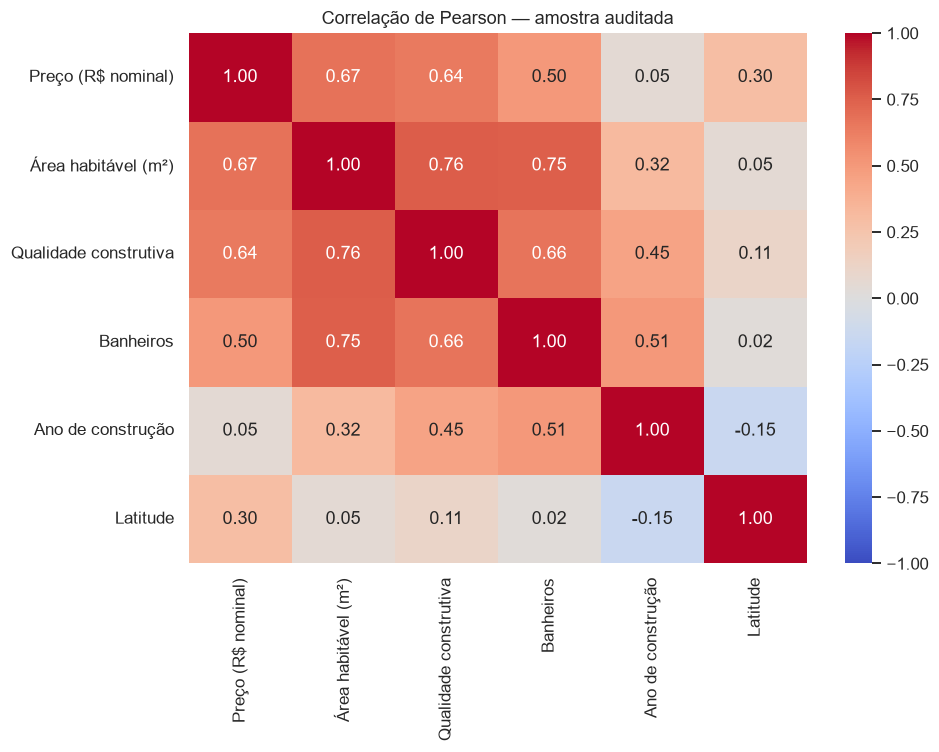

area        0,67299
grade       0,64106
bathrooms   0,50297
lat         0,29554
yr_built    0,05231
Name: correlacao_com_preco, dtype: float64

Correlação área/preço em US$: 0,7020
Correlação área/preço em R$: 0,6730


In [10]:
rotulos = {'preco': 'Preço (R$ nominal)', 'area': 'Área habitável (m²)',
           'grade': 'Qualidade construtiva', 'bathrooms': 'Banheiros',
           'yr_built': 'Ano de construção', 'lat': 'Latitude'}
correlacoes = base_ajustada[variaveis].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(correlacoes.rename(index=rotulos, columns=rotulos), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlação de Pearson — amostra auditada')
plt.tight_layout()
salvar_grafico(plt.gcf(), '03_correlacoes.png', recorte=None)
display(correlacoes['preco'].drop('preco').sort_values(ascending=False).rename('correlacao_com_preco'))
print('Correlação área/preço em US$:', formatar_valor(base_ajustada['area'].corr(base_ajustada['price']), 4))
print('Correlação área/preço em R$:', formatar_valor(base_ajustada['area'].corr(base_ajustada['preco']), 4))

## 8. Formulação e ajuste do MRLS

\[
preco_i = \beta_0 + \beta_1\,area_i + \varepsilon_i
\]

O MQO estima o intercepto e a inclinação pela minimização da soma dos quadrados dos resíduos, \(SQR = \sum_i(preco_i-\widehat{preco}_i)^2\). Sob a hipótese \(E(\varepsilon_i\mid area_i)=0\), a reta representa a média condicional proposta pelo modelo.

O **erro teórico** \(\varepsilon_i\) não é observado. O **resíduo**, calculado após o ajuste, é a diferença \(e_i=preco_i-\widehat{preco}_i\).

O modelo inclui intercepto e utiliza todas as vendas auditadas, com o mesmo peso por venda. Para a inclinação, o teste é bilateral: \(H_0:\beta_1=0\) contra \(H_1:\beta_1\neq0\), com \(\alpha=0{,}05\).

Erros padrão, testes e intervalos utilizam inferência clássica, condicionada aos pressupostos dos erros, incluindo independência e variância constante. Esses pressupostos são examinados nas seções de diagnóstico, com atenção à possível dependência entre revendas. Um valor-p reduzido não mede importância econômica nem demonstra causalidade.

In [11]:
if len(base_ajustada) < 3 or base_ajustada['area'].nunique() < 2:
    raise ValueError('O MRLS exige pelo menos três vendas e variação na área.')
if not np.isfinite(base_ajustada[['preco', 'area']].to_numpy()).all():
    raise ValueError('Confira preço e área antes de ajustar o MRLS.')

modelo_simples = ajustar_modelo(base_ajustada, 'preco ~ area')
base_ajustada['preco_estimado'] = modelo_simples.fittedvalues
base_ajustada['residuo'] = modelo_simples.resid
coeficientes = tabela_coef(modelo_simples, {'Intercept': 'R$', 'area': 'R$/m²'})

display(coeficientes.rename(index={'Intercept': 'Intercepto', 'area': 'Área habitável'}))
salvar_tabela(coeficientes, 'coeficientes_mrls.csv', indice=True)

intercepto = modelo_simples.params['Intercept']
coeficiente_area = modelo_simples.params['area']
display(Markdown(
    f'**Equação estimada:** preço estimado (R$) = {formatar_valor(intercepto)} + '
    f'{formatar_valor(coeficiente_area)} × área (m²).\n\n'
    f'Uma diferença de 10 m² corresponde a uma diferença média estimada de '
    f'R$ {formatar_valor(10 * coeficiente_area)} entre os valores da reta; '
    f'para 100 m², R$ {formatar_valor(100 * coeficiente_area)}. '
    'A inclinação não equivale ao preço médio por m² de um imóvel nem ao efeito causal de ampliá-lo.\n\n'
    f'O intercepto corresponde a área zero, fora da faixa observada de '
    f'{formatar_valor(base_ajustada["area"].min())} a {formatar_valor(base_ajustada["area"].max())} m². '
    'Sua interpretação como preço de um imóvel não é adequada.\n\n'
    'O erro padrão quantifica a incerteza do coeficiente, distinta da dispersão residual. '
    'O IC de 95% usa um procedimento que, sob seus pressupostos, cobre o parâmetro em '
    '95% das repetições hipotéticas da amostragem; não atribui probabilidade ao parâmetro neste intervalo.'
))

,coeficiente,erro_padrao,estatistica_t,valor_p,ic_inferior,ic_superior,unidade
termo,,,,,,,
Intercepto,"-86.607,14","11.962,13","-7,24","< 0,001","-110.053,80","-63.160,49",R$
Área habitável,"7.574,84","56,63","133,76","< 0,001","7.463,84","7.685,84",R$/m²


**Equação estimada:** preço estimado (R$) = -86.607,14 + 7.574,84 × área (m²).

Uma diferença de 10 m² corresponde a uma diferença média estimada de R$ 75.748,40 entre os valores da reta; para 100 m², R$ 757.483,95. A inclinação não equivale ao preço médio por m² de um imóvel nem ao efeito causal de ampliá-lo.

O intercepto corresponde a área zero, fora da faixa observada de 26,94 a 1.257,91 m². Sua interpretação como preço de um imóvel não é adequada.

O erro padrão quantifica a incerteza do coeficiente, distinta da dispersão residual. O IC de 95% usa um procedimento que, sob seus pressupostos, cobre o parâmetro em 95% das repetições hipotéticas da amostragem; não atribui probabilidade ao parâmetro neste intervalo.

## 9. Qualidade do ajuste e referência em dólares

Com intercepto, \(R^2=1-SQR/SQT\), em que \(SQT\) mede a variabilidade dos preços em torno da média amostral. O R² expressa a proporção dessa variabilidade descrita pela reta **na amostra**; não é uma taxa de acerto nem uma medida de efeito causal.

O erro padrão residual é \(\sqrt{SQR/(n-2)}\), expresso em reais. Ele mede a dispersão dos resíduos e não equivale ao erro médio absoluto ou a uma margem fixa de erro para cada venda.

No MRLS clássico, o teste F avalia a hipótese de inclinação zero. A estatística F é igual ao quadrado da estatística t da área, \(F=t^2\), e os dois testes produzem a mesma conclusão quando o teste t é bilateral.

O ajuste de referência `price ~ area` utiliza as mesmas vendas, com os preços originais em dólares. A diferença entre os R² evidencia o efeito da mudança de resposta, sem estabelecer superioridade preditiva de um ajuste sobre o outro.

In [12]:
medidas_simples = resumir_medidas(modelo_simples)
erro_residual = medidas_simples['erro_residual']
medidas_ajuste = pd.DataFrame({
    'medida': ['n_vendas', 'r2', 'r2_ajustado', 'sqr', 'erro_residual', 'estatistica_f', 'gl_modelo', 'gl_residuo', 'valor_p_f'],
    'valor': [medidas_simples[medida] for medida in
              ['vendas', 'r2', 'r2_ajustado', 'sqr', 'erro_residual', 'estatistica_f',
               'gl_modelo', 'gl_residuo', 'valor_p_f']],
    'unidade': ['vendas', 'proporção', 'proporção', 'R$²', 'R$', 'sem unidade', 'graus de liberdade', 'graus de liberdade', 'sem unidade']
}).set_index('medida')
medidas_exibidas = medidas_ajuste.copy()
for medida, linha in medidas_ajuste.iterrows():
    valor = linha['valor']
    if medida in ['r2', 'r2_ajustado']:
        exibido = formatar_valor(valor, 5)
    elif medida == 'sqr':
        exibido = f'{valor:.5e}'.replace('.', ',')
    elif medida in ['n_vendas', 'gl_modelo', 'gl_residuo']:
        exibido = formatar_valor(valor, 0)
    elif medida == 'valor_p_f':
        exibido = valor
    else:
        exibido = formatar_valor(valor)
    medidas_exibidas.loc[medida, 'valor'] = exibido
display(medidas_exibidas)
salvar_tabela(medidas_ajuste, 'medidas_mrls.csv', indice=True)

modelo_dolar = ajustar_modelo(base_ajustada, 'price ~ area')
referencia_cambio = pd.DataFrame({
    'resposta': ['US$ original', 'R$ nominal histórico'],
    'vendas': [int(modelo_dolar.nobs), int(modelo_simples.nobs)],
    'correlacao_area': [base_ajustada['area'].corr(base_ajustada['price']), base_ajustada['area'].corr(base_ajustada['preco'])],
    'r2': [modelo_dolar.rsquared, modelo_simples.rsquared]
})
display(referencia_cambio.assign(
    correlacao_area=referencia_cambio['correlacao_area'].map(lambda valor: formatar_valor(valor, 4)),
    r2=referencia_cambio['r2'].map(lambda valor: formatar_valor(valor, 5))
))
salvar_tabela(referencia_cambio, 'referencia_cambio.csv')
display(Markdown(
    f'A reta descreve **{formatar_valor(100 * modelo_simples.rsquared)}%** da variabilidade '
    f'dos preços em reais na amostra. Os **{formatar_valor(100 * (1 - modelo_simples.rsquared))}%** '
    'restantes são variabilidade residual, não atribuível integralmente às demais características.\n\n'
    f'O erro padrão residual é **R$ {formatar_valor(erro_residual)}**; há dispersão expressiva '
    'dos preços observados em torno da reta. A proximidade entre R² e R² ajustado é esperada '
    'em uma amostra grande com uma explicativa e não valida o modelo por si só.\n\n'
    f'O teste clássico apresentou F(1, {int(modelo_simples.df_resid)}) = '
    f'{formatar_valor(modelo_simples.fvalue)}, com p {formatar_p(modelo_simples.f_pvalue)}. '
    'A evidência contra a inclinação zero é condicionada aos pressupostos da inferência.\n\n'
    f'Na referência em dólares, R² = {formatar_valor(100 * modelo_dolar.rsquared)}%; '
    f'a diferença é de {formatar_valor(100 * (modelo_dolar.rsquared - modelo_simples.rsquared))} '
    'pontos percentuais, calculada antes do arredondamento. O câmbio histórico altera a resposta analisada.'
))

,valor,unidade
medida,,
n_vendas,21.613,vendas
r2,"0,45291",proporção
r2_ajustado,"0,45289",proporção
sqr,"1,09054e+16",R$²
erro_residual,"710.368,84",R$
estatistica_f,"17.891,07",sem unidade
gl_modelo,1,graus de liberdade
gl_residuo,21.611,graus de liberdade
valor_p_f,"< 0,001",sem unidade


,resposta,vendas,correlacao_area,r2
0,US$ original,21613,"0,7020","0,49285"
1,R$ nominal histórico,21613,"0,6730","0,45291"


A reta descreve **45,29%** da variabilidade dos preços em reais na amostra. Os **54,71%** restantes são variabilidade residual, não atribuível integralmente às demais características.

O erro padrão residual é **R$ 710.368,84**; há dispersão expressiva dos preços observados em torno da reta. A proximidade entre R² e R² ajustado é esperada em uma amostra grande com uma explicativa e não valida o modelo por si só.

O teste clássico apresentou F(1, 21611) = 17.891,07, com p < 0,001. A evidência contra a inclinação zero é condicionada aos pressupostos da inferência.

Na referência em dólares, R² = 49,29%; a diferença é de 3,99 pontos percentuais, calculada antes do arredondamento. O câmbio histórico altera a resposta analisada.

## 10. Dispersão com a reta ajustada

O gráfico apresenta todas as vendas utilizadas no ajuste, em escala linear, com preço em milhões de reais nominais. A reta é traçada entre a menor e a maior área observada, evitando extrapolação visual. A transparência dos pontos facilita a leitura das sobreposições.

A reta descreve a relação linear estimada. A diferença entre o preço observado e o valor da reta, para a mesma área, corresponde ao resíduo na escala do gráfico: observações acima da reta apresentam resíduos positivos, enquanto observações abaixo apresentam resíduos negativos. O gráfico não apresenta uma margem fixa de erro nem substitui a avaliação dos pressupostos.

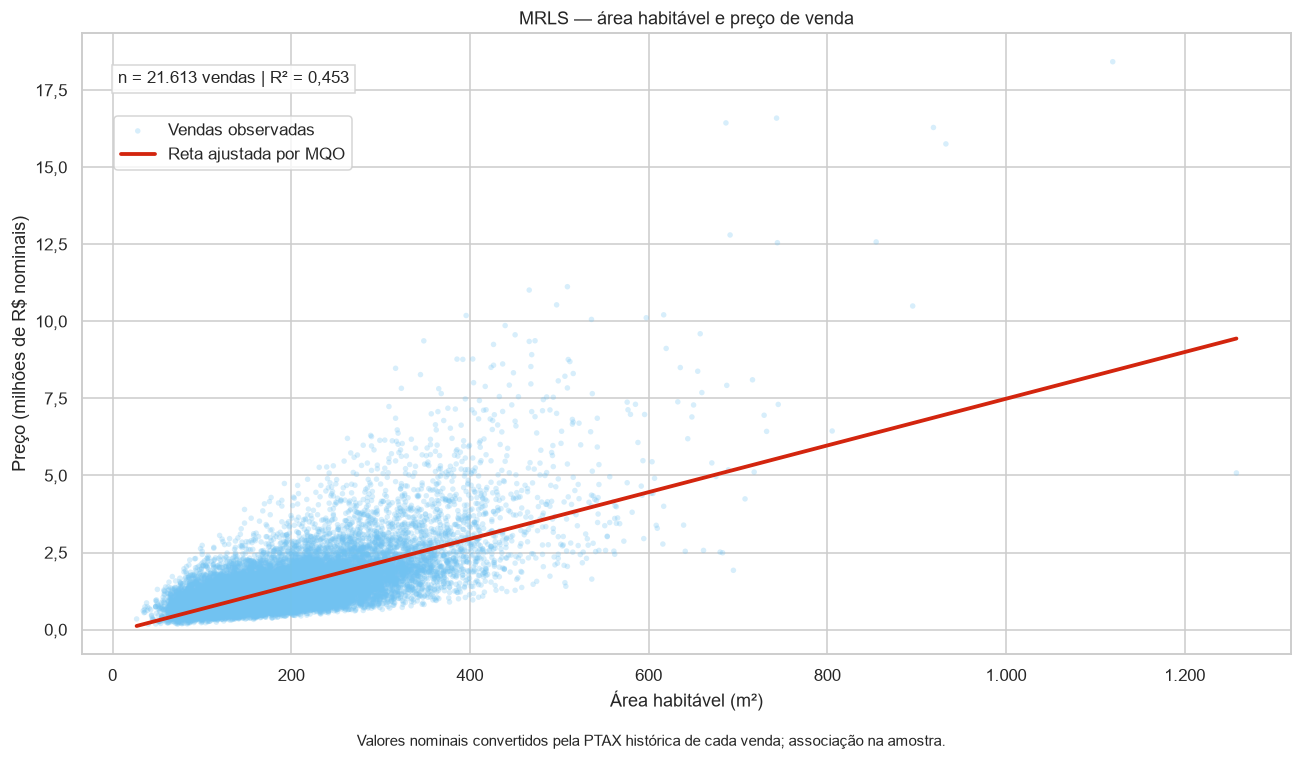

In [13]:
area_reta = pd.DataFrame({'area': np.linspace(base_ajustada['area'].min(), base_ajustada['area'].max(), 300)})
preco_reta = modelo_simples.predict(area_reta)
fig, eixo = plt.subplots(figsize=(12, 7))
eixo.scatter(base_ajustada['area'], base_ajustada['preco'] / 1e6,
             s=13, alpha=0.28, color=AZUL, edgecolors='none', label='Vendas observadas')
eixo.plot(area_reta['area'], preco_reta / 1e6,
          color=VERMELHO, linewidth=2.5, label='Reta ajustada por MQO')
eixo.set(xlabel='Área habitável (m²)', ylabel='Preço (milhões de R$ nominais)',
         title='MRLS — área habitável e preço de venda')
eixo.xaxis.set_major_formatter(FuncFormatter(lambda valor, posicao: formatar_valor(valor, 0)))
eixo.yaxis.set_major_formatter(FuncFormatter(lambda valor, posicao: formatar_valor(valor, 1)))
eixo.text(0.03, 0.94,
          f'n = {formatar_valor(modelo_simples.nobs, 0)} vendas | R² = {formatar_valor(modelo_simples.rsquared, 3)}',
          transform=eixo.transAxes, va='top', fontsize=11,
          bbox={'facecolor': 'white', 'alpha': 0.9, 'edgecolor': 'lightgray'})
eixo.legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))
fig.text(0.5, 0.02, 'Valores nominais convertidos pela PTAX histórica de cada venda; associação na amostra.',
         ha='center', fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 1))
salvar_grafico(fig, '04_ajuste_mrls.png')

## 11. Síntese da análise descritiva e do MRLS

A auditoria, as conversões e a análise das revendas sustentam a descrição da amostra e o ajuste do MRLS. A interpretação do ajuste distingue a magnitude da associação, a incerteza dos coeficientes, a variabilidade descrita e a dispersão residual.

Por utilizar apenas a área habitável como explicativa, o MRLS descreve uma associação bivariada que reúne diferenças entre as vendas, incluindo características dos imóveis e variação cambial. O modelo não identifica separadamente essas contribuições.

As seções seguintes ampliam o modelo para outras características e examinam os resíduos. Os resultados inferenciais dependem dos pressupostos avaliados nesses diagnósticos; as limitações observacionais e a possível dependência entre revendas permanecem. O ajuste na amostra não estabelece causalidade nem precisão para vendas futuras.

In [14]:
display(Markdown(
    f'Foram analisadas **{formatar_valor(len(base_ajustada), 0)} vendas**, correspondentes a '
    f'**{formatar_valor(base_ajustada["id"].nunique(), 0)} imóveis**, de '
    f'{base_ajustada["date"].min():%d/%m/%Y} a {base_ajustada["date"].max():%d/%m/%Y}. '
    f'A auditoria excluiu {len(excluidos)} vendas; '
    f'{len(analise_ids)} propriedades apresentaram mais de uma venda.\n\n'
    f'A inclinação estimada foi **R$ {formatar_valor(coeficiente_area)}/m²**, '
    f'com IC de 95% de R$ {formatar_valor(coeficientes.loc["area", "ic_inferior"])} a '
    f'R$ {formatar_valor(coeficientes.loc["area", "ic_superior"])}/m² e p {formatar_p(modelo_simples.pvalues["area"])} '
    'sob inferência clássica. '
    f'A reta descreveu **{formatar_valor(100 * modelo_simples.rsquared)}%** da variabilidade '
    f'dos preços nominais em reais, com erro padrão residual de **R$ {formatar_valor(erro_residual)}**. '
    'A associação é positiva, mas permanece dispersão relevante entre as vendas.'
))

Foram analisadas **21.613 vendas**, correspondentes a **21.436 imóveis**, de 02/05/2014 a 27/05/2015. A auditoria excluiu 0 vendas; 176 propriedades apresentaram mais de uma venda.

A inclinação estimada foi **R$ 7.574,84/m²**, com IC de 95% de R$ 7.463,84 a R$ 7.685,84/m² e p < 0,001 sob inferência clássica. A reta descreveu **45,29%** da variabilidade dos preços nominais em reais, com erro padrão residual de **R$ 710.368,84**. A associação é positiva, mas permanece dispersão relevante entre as vendas.

## 12. Regressão múltipla e resposta em log

O MRLM inclui área habitável, qualidade construtiva, banheiros, ano de construção e latitude:

\[
preco_i = \beta_0 + \beta_1 area_i + \beta_2 grade_i + \beta_3 bathrooms_i + \beta_4 yr\_built_i + \beta_5 lat_i + \varepsilon_i.
\]

A versão com resposta em log utiliza \(log\_preco_i=\ln(preco_i/1\,R\$)\), mantendo as mesmas cinco explicativas. Essa mudança de escala é avaliada pelos diagnósticos; não se presume que resolva a heterocedasticidade ou a não normalidade.

Os três modelos principais utilizam as mesmas vendas da `base_ajustada`. O ajuste requer preditoras finitas, completas e compatíveis com seus domínios; não há descarte silencioso de linhas. Revendas e registros extremos permanecem na amostra.

A especificação trata `grade` numericamente, supondo uma mudança linear uniforme por ponto da escala ordinal. `yr_built` representa o ano de construção, e `lat` descreve apenas parte da localização.

In [15]:
preditoras = ['area', 'grade', 'bathrooms', 'yr_built', 'lat']

def validar_modelos(base):
    campos = ['preco'] + preditoras
    if base.empty or not np.isfinite(base[campos].to_numpy(dtype=float)).all():
        raise ValueError('Confira os registros sinalizados: preço e preditoras do MRLM precisam ser finitos e completos.')
    if ((base['preco'] <= 0).any() or (base['area'] <= 0).any()
            or (base['bathrooms'] < 0).any() or (base['yr_built'] <= 0).any()
            or not base['grade'].between(1, 13).all() or not base['lat'].between(-90, 90).all()):
        raise ValueError('Há valores incompatíveis com o domínio das variáveis do MRLM; revise a auditoria.')
    matriz = sm.add_constant(base[preditoras], has_constant='add').to_numpy(dtype=float)
    if len(base) <= matriz.shape[1] or np.linalg.matrix_rank(matriz) != matriz.shape[1]:
        raise ValueError('O MRLM precisa de graus de liberdade residuais e de uma matriz de preditoras com posto completo.')

validar_modelos(base_ajustada)
base_ajustada['log_preco'] = np.log(base_ajustada['preco'])
formula_multipla = 'preco ~ area + grade + bathrooms + yr_built + lat'
formula_log = 'log_preco ~ area + grade + bathrooms + yr_built + lat'
modelo_multiplo = ajustar_modelo(base_ajustada, formula_multipla)
modelo_log = ajustar_modelo(base_ajustada, formula_log)
modelos_ajustados = {'MRLS': modelo_simples, 'MRLM': modelo_multiplo, 'MRLM_log': modelo_log}
base_ajustada['preco_multiplo'] = modelo_multiplo.fittedvalues
base_ajustada['residuo_multiplo'] = modelo_multiplo.resid
base_ajustada['log_estimado'] = modelo_log.fittedvalues
base_ajustada['residuo_log'] = modelo_log.resid
print('Amostra comum dos três modelos:', len(base_ajustada), 'vendas')

Amostra comum dos três modelos: 21613 vendas


## 13. Coeficientes, interpretação condicional e comparação

No MRLM, cada coeficiente expressa uma associação **mantendo as demais explicativas constantes**, dentro da especificação observacional. O modelo controla somente as características incluídas, sem demonstrar causalidade. O intercepto corresponde a uma combinação de zeros fora do domínio substantivo dos dados.

Para uma diferença \(\delta\) em uma preditora:

- No **MRLM em reais**, a diferença entre os valores médios ajustados é \(\widehat{\beta}_j\delta\) reais.
- No **MRLM com resposta em log**, \(100[\exp(\widehat{\beta}_j\delta)-1]\) expressa a variação percentual da média geométrica condicional proposta pelo modelo, obtida exponenciando o log médio estimado.

A retransformação do log ajustado não recupera automaticamente a média aritmética do preço em reais. Uma previsão nessa escala exige explicitar o procedimento utilizado.

R², R² ajustado e erro padrão residual são apresentados junto de sua escala. MRLS e MRLM em reais permitem comparar o ajuste para a mesma resposta e as mesmas vendas. O R² do modelo em log descreve **outra resposta** e não permite classificá-lo diretamente como superior aos modelos em reais.

Erros padrão, valores-p e intervalos de confiança permanecem clássicos e condicionados aos pressupostos dos erros. Os diagnósticos seguintes examinam suas limitações.

In [16]:
unidades_lineares = {'Intercept': 'R$', 'area': 'R$/m²', 'grade': 'R$/ponto',
                    'bathrooms': 'R$/banheiro', 'yr_built': 'R$/ano', 'lat': 'R$/grau'}
unidades_log = {'Intercept': 'log do preço', 'area': 'log do preço/m²', 'grade': 'log do preço/ponto',
               'bathrooms': 'log do preço/banheiro', 'yr_built': 'log do preço/ano', 'lat': 'log do preço/grau'}

def resumir_modelo(modelo, nome):
    escala = 'log do preço em R$' if nome == 'MRLM_log' else 'R$ nominal'
    unidades = unidades_log if nome == 'MRLM_log' else unidades_lineares
    coeficientes_modelo = tabela_coef(modelo, unidades).reset_index()
    coeficientes_modelo.insert(0, 'escala_resposta', escala)
    coeficientes_modelo.insert(0, 'modelo', nome)
    coeficientes_modelo['covariancia'] = modelo.cov_type
    medidas = resumir_medidas(modelo)
    medidas.pop('gl_modelo')
    medidas_modelo = {'modelo': nome, 'escala_resposta': escala, **medidas}
    return coeficientes_modelo, medidas_modelo

tabelas_coeficientes, registros_medidas = [], []
for nome, modelo in modelos_ajustados.items():
    tabela_modelo, medidas_modelo = resumir_modelo(modelo, nome)
    tabelas_coeficientes.append(tabela_modelo)
    registros_medidas.append(medidas_modelo)
    tabela_exibida = tabela_modelo[['termo', 'coeficiente', 'erro_padrao', 'estatistica_t',
                                    'valor_p', 'ic_inferior', 'ic_superior', 'unidade']].copy()
    casas = 6 if nome == 'MRLM_log' else 2
    for coluna in ['coeficiente', 'erro_padrao', 'ic_inferior', 'ic_superior']:
        tabela_exibida[coluna] = tabela_exibida[coluna].map(lambda valor: formatar_valor(valor, casas))
    display(Markdown(f'**{nome} — coeficientes e inferência clássica**'))
    display(tabela_exibida)
coeficientes_modelos = pd.concat(tabelas_coeficientes, ignore_index=True)
medidas_modelos = pd.DataFrame(registros_medidas)
salvar_tabela(coeficientes_modelos, 'coeficientes_modelos.csv')
salvar_tabela(medidas_modelos, 'medidas_modelos.csv')
display(medidas_modelos[['modelo', 'escala_resposta', 'vendas', 'r2', 'r2_ajustado', 'erro_residual']].assign(
    r2=medidas_modelos['r2'].map(lambda valor: formatar_valor(valor, 5)),
    r2_ajustado=medidas_modelos['r2_ajustado'].map(lambda valor: formatar_valor(valor, 5)),
    erro_residual=medidas_modelos['erro_residual'].map(lambda valor: formatar_valor(valor, 4))
))

variacoes = {'area': 10, 'grade': 1, 'bathrooms': 1, 'yr_built': 10, 'lat': 0.01}
efeitos_modelos = pd.DataFrame([
    {'variavel': variavel, 'variacao': variacao,
     'diferenca_reais': modelo_multiplo.params[variavel] * variacao,
     'variacao_geometrica_pct': 100 * np.expm1(modelo_log.params[variavel] * variacao)}
    for variavel, variacao in variacoes.items()
])
display(Markdown('**Diferenças ajustadas no MRLM, mantendo as demais explicativas constantes**'))
display(efeitos_modelos)
salvar_tabela(efeitos_modelos, 'efeitos_modelos.csv')
display(Markdown(
    f'No MRLM em reais, uma diferença de 10 m² está associada a uma diferença ajustada de '
    f'**R$ {formatar_valor(10 * modelo_multiplo.params["area"])}**, mantendo as demais explicativas constantes. '
    f'No modelo log, essa diferença corresponde a **{formatar_valor(100 * np.expm1(10 * modelo_log.params["area"]))}%** '
    'no preço geométrico proposto. São associações condicionais, sem interpretação causal.\n\n'
    f'O MRLS e o MRLM descrevem, respectivamente, **{formatar_valor(100 * modelo_simples.rsquared)}%** e '
    f'**{formatar_valor(100 * modelo_multiplo.rsquared)}%** da variabilidade dos preços nominais em reais na mesma amostra. '
    f'O R² do MRLM log é **{formatar_valor(modelo_log.rsquared, 5)}** e descreve a variabilidade do log do preço.'
))

**MRLS — coeficientes e inferência clássica**

,termo,coeficiente,erro_padrao,estatistica_t,valor_p,ic_inferior,ic_superior,unidade
0,Intercept,"-86.607,14","11.962,13","-7,24","< 0,001","-110.053,80","-63.160,49",R$
1,area,"7.574,84","56,63","133,76","< 0,001","7.463,84","7.685,84",R$/m²


**MRLM — coeficientes e inferência clássica**

,termo,coeficiente,erro_padrao,estatistica_t,valor_p,ic_inferior,ic_superior,unidade
0,Intercept,"-49.125.043,54","1.589.054,25","-30,91","< 0,001","-52.239.707,12","-46.010.379,96",R$
1,area,"4.492,84","91,12","49,31","< 0,001","4.314,25","4.671,43",R$/m²
2,grade,"309.890,44","5.941,91","52,15","< 0,001","298.243,85","321.537,02",R$/ponto
3,bathrooms,"90.419,57","9.176,36","9,85","< 0,001","72.433,23","108.405,92",R$/banheiro
4,yr_built,"-8.252,58","177,05","-46,61","< 0,001","-8.599,61","-7.905,56",R$/ano
5,lat,"1.331.702,59","31.207,64","42,67","< 0,001","1.270.533,31","1.392.871,87",R$/grau


**MRLM_log — coeficientes e inferência clássica**

,termo,coeficiente,erro_padrao,estatistica_t,valor_p,ic_inferior,ic_superior,unidade
0,Intercept,"-41,486596","0,796755","-52,07","< 0,001","-43,048295","-39,924897",log do preço
1,area,"0,001995","0,000046","43,67","< 0,001","0,001906","0,002085",log do preço/m²
2,grade,"0,193582","0,002979","64,98","< 0,001","0,187743","0,199422",log do preço/ponto
3,bathrooms,"0,079593","0,004601","17,30","< 0,001","0,070574","0,088611",log do preço/banheiro
4,yr_built,"-0,004022","0,000089","-45,31","< 0,001","-0,004196","-0,003848",log do preço/ano
5,lat,"1,290023","0,015648","82,44","< 0,001","1,259352","1,320693",log do preço/grau


,modelo,escala_resposta,vendas,r2,r2_ajustado,erro_residual
0,MRLS,R$ nominal,21613,"0,45291","0,45289","710.368,8419"
1,MRLM,R$ nominal,21613,"0,59183","0,59174","613.642,4553"
2,MRLM_log,log do preço em R$,21613,"0,67761","0,67753","0,3077"


**Diferenças ajustadas no MRLM, mantendo as demais explicativas constantes**

,variavel,variacao,diferenca_reais,variacao_geometrica_pct
0,area,"10,00","44.928,40","2,02"
1,grade,"1,00","309.890,44","21,36"
2,bathrooms,"1,00","90.419,57","8,28"
3,yr_built,"10,00","-82.525,83","-3,94"
4,lat,"0,01","13.317,03","1,30"


No MRLM em reais, uma diferença de 10 m² está associada a uma diferença ajustada de **R$ 44.928,40**, mantendo as demais explicativas constantes. No modelo log, essa diferença corresponde a **2,02%** no preço geométrico proposto. São associações condicionais, sem interpretação causal.

O MRLS e o MRLM descrevem, respectivamente, **45,29%** e **59,18%** da variabilidade dos preços nominais em reais na mesma amostra. O R² do MRLM log é **0,67761** e descreve a variabilidade do log do preço.

### 13.1. Interpretação das preditoras do MRLM em reais

Os contrastes apresentados variam uma preditora por vez e mantêm as outras quatro constantes na equação. Cada diferença é calculada por `coeficiente * variacao`, com as mesmas variações da tabela anterior.

Os valores representam diferenças entre médias ajustadas em **reais nominais**, sem interpretação causal ou garantia de que existam pares de imóveis com essas características na amostra. Esta seção se refere ao MRLM em reais; a interpretação multiplicativa do modelo em log é apresentada na seção 13.

In [17]:
contrastes = efeitos_modelos.set_index('variavel')
display(Markdown(
    f'**Área habitável:** para uma área **{formatar_valor(contrastes.loc["area", "variacao"], 0)} m² maior**, '
    f'o MRLM associa uma diferença média ajustada de **R$ {formatar_valor(contrastes.loc["area", "diferenca_reais"])}**. '
    'A inclinação expressa uma associação condicional em R$/m², distinta do preço médio por m² de um imóvel.\n\n'
    f'**Qualidade construtiva (`grade`):** um acréscimo de **{formatar_valor(contrastes.loc["grade", "variacao"], 0)}** '
    f'na escala está associado a uma diferença ajustada de **R$ {formatar_valor(contrastes.loc["grade", "diferenca_reais"])}**. '
    'Como a escala é ordinal, o uso numérico supõe a mesma diferença linear por ponto, '
    'sem demonstrar que intervalos entre níveis tenham igual significado substantivo.\n\n'
    f'**Banheiros (`bathrooms`):** um acréscimo de **{formatar_valor(contrastes.loc["bathrooms", "variacao"], 0)}** '
    f'na contagem registrada está associado a uma diferença ajustada de '
    f'**R$ {formatar_valor(contrastes.loc["bathrooms", "diferenca_reais"])}**. '
    'A coluna admite contagens fracionárias; o contraste descreve a associação com essa medida cadastral.\n\n'
    f'**Ano de construção (`yr_built`):** um ano de construção '
    f'**{formatar_valor(contrastes.loc["yr_built", "variacao"], 0)} anos mais recente** '
    f'está associado a uma diferença ajustada de **R$ {formatar_valor(contrastes.loc["yr_built", "diferenca_reais"])}**. '
    'A comparação usa anos de construção de imóveis com as demais preditoras constantes na equação; '
    'não corresponde ao envelhecimento do mesmo imóvel ao longo do tempo.\n\n'
    f'**Latitude (`lat`):** uma latitude **{formatar_valor(contrastes.loc["lat", "variacao"], 2)} grau maior**, '
    f'em direção ao norte, está associada a uma diferença ajustada de '
    f'**R$ {formatar_valor(contrastes.loc["lat", "diferenca_reais"])}**. '
    'Essa associação espacial se refere à região estudada. A latitude representa apenas parte da localização; '
    'o coeficiente não identifica um mecanismo específico de valorização nem substitui informações de bairro ou longitude.'
))


**Área habitável:** para uma área **10 m² maior**, o MRLM associa uma diferença média ajustada de **R$ 44.928,40**. A inclinação expressa uma associação condicional em R$/m², distinta do preço médio por m² de um imóvel.

**Qualidade construtiva (`grade`):** um acréscimo de **1** na escala está associado a uma diferença ajustada de **R$ 309.890,44**. Como a escala é ordinal, o uso numérico supõe a mesma diferença linear por ponto, sem demonstrar que intervalos entre níveis tenham igual significado substantivo.

**Banheiros (`bathrooms`):** um acréscimo de **1** na contagem registrada está associado a uma diferença ajustada de **R$ 90.419,57**. A coluna admite contagens fracionárias; o contraste descreve a associação com essa medida cadastral.

**Ano de construção (`yr_built`):** um ano de construção **10 anos mais recente** está associado a uma diferença ajustada de **R$ -82.525,83**. A comparação usa anos de construção de imóveis com as demais preditoras constantes na equação; não corresponde ao envelhecimento do mesmo imóvel ao longo do tempo.

**Latitude (`lat`):** uma latitude **0,01 grau maior**, em direção ao norte, está associada a uma diferença ajustada de **R$ 13.317,03**. Essa associação espacial se refere à região estudada. A latitude representa apenas parte da localização; o coeficiente não identifica um mecanismo específico de valorização nem substitui informações de bairro ou longitude.

### 13.2. Associações simples e condicionais

A correlação de Pearson descreve a associação bivariada de cada preditora com o preço. O coeficiente do MRLM descreve a associação condicional às outras características e possui a unidade indicada na tabela.

**Correlação e coeficiente são medidas distintas:** seus sinais permitem examinar a direção das associações, mas suas magnitudes numéricas não são diretamente comparáveis.

As inclinações da área no MRLS e no MRLM, por sua vez, utilizam a mesma unidade, resposta e amostra. Essa comparação evidencia que a estimativa depende da especificação e da distribuição conjunta das preditoras, sem atribuir às diferenças uma decomposição causal do preço.

In [18]:
associacoes = pd.DataFrame({
    'variavel': preditoras,
    'correlacao_preco': correlacoes.loc[preditoras, 'preco'].to_numpy(),
    'coef_mrlm': [modelo_multiplo.params[variavel] for variavel in preditoras],
    'unidade': [unidades_lineares[variavel] for variavel in preditoras]
})
display(associacoes.assign(
    correlacao_preco=associacoes['correlacao_preco'].map(lambda valor: formatar_valor(valor, 5)),
    coef_mrlm=associacoes['coef_mrlm'].map(formatar_valor)
))
salvar_tabela(associacoes, 'associacoes_mrlm.csv')

corr_ano = correlacoes.loc['yr_built', 'preco']
coef_ano = modelo_multiplo.params['yr_built']
mudanca_sinal = np.sign(corr_ano) != np.sign(coef_ano)
leitura_ano = (
    'A mudança de sinal observada reflete comparações distintas e a estrutura conjunta dos dados. '
    if mudanca_sinal else
    'Os sinais coincidem nesta amostra, embora descrevam comparações distintas. '
)
display(Markdown(
    f'**Mudança na magnitude da associação com a área:** a inclinação passa de '
    f'**R$ {formatar_valor(modelo_simples.params["area"])}/m²** no MRLS para '
    f'**R$ {formatar_valor(modelo_multiplo.params["area"])}/m²** no MRLM. '
    f'Para {formatar_valor(contrastes.loc["area", "variacao"], 0)} m², os contrastes são '
    f'**R$ {formatar_valor(modelo_simples.params["area"] * contrastes.loc["area", "variacao"])}** e '
    f'**R$ {formatar_valor(contrastes.loc["area", "diferenca_reais"])}**, respectivamente.\n\n'
    f'**Ano de construção:** a correlação simples com o preço é '
    f'**{formatar_valor(corr_ano, 5)}**, enquanto o coeficiente condicional é '
    f'**R$ {formatar_valor(coef_ano)}/ano**. '
    + leitura_ano
    + 'A correlação não tem unidade; o coeficiente está em R$/ano. '
    'Uma diferença de sinal não é automaticamente um erro do ajuste. '
    'A especificação não identifica qual característica produziu essa diferença nem demonstra '
    'um efeito causal do ano de construção sobre o preço.'
))


,variavel,correlacao_preco,coef_mrlm,unidade
0,area,"0,67299","4.492,84",R$/m²
1,grade,"0,64106","309.890,44",R$/ponto
2,bathrooms,"0,50297","90.419,57",R$/banheiro
3,yr_built,"0,05231","-8.252,58",R$/ano
4,lat,"0,29554","1.331.702,59",R$/grau


**Mudança na magnitude da associação com a área:** a inclinação passa de **R$ 7.574,84/m²** no MRLS para **R$ 4.492,84/m²** no MRLM. Para 10 m², os contrastes são **R$ 75.748,40** e **R$ 44.928,40**, respectivamente.

**Ano de construção:** a correlação simples com o preço é **0,05231**, enquanto o coeficiente condicional é **R$ -8.252,58/ano**. A mudança de sinal observada reflete comparações distintas e a estrutura conjunta dos dados. A correlação não tem unidade; o coeficiente está em R$/ano. Uma diferença de sinal não é automaticamente um erro do ajuste. A especificação não identifica qual característica produziu essa diferença nem demonstra um efeito causal do ano de construção sobre o preço.

### 13.3. Faixas observadas e limites dos contrastes

A tabela seguinte apresenta os **limites individuais** das preditoras na amostra do MRLM. Os exemplos devem respeitar essas faixas e a codificação de cada variável: acrescentar um ponto ao maior `grade` observado ou utilizar um ano de construção superior ao máximo da base ultrapassa os limites registrados.

Estar dentro das faixas individuais **não garante que a combinação conjunta** de área, qualidade, banheiros, ano e latitude esteja representada na amostra. O suporte conjunto dos contrastes não foi verificado; os valores ilustram a equação e não devem ser atribuídos indiscriminadamente a qualquer imóvel.

A interpretação de um cenário específico requer examinar observações próximas nas cinco preditoras e evitar combinações raras ou extrapolações. A capacidade preditiva para novos cenários ainda não foi avaliada. A interpretação dos coeficientes e intervalos continua sujeita às limitações da especificação e da inferência clássica.

In [19]:
faixas_preditoras = base_ajustada[preditoras].agg(['min', 'max']).T.rename(
    columns={'min': 'minimo', 'max': 'maximo'}
).rename_axis('variavel').reset_index()
faixas_preditoras['unidade'] = faixas_preditoras['variavel'].map(unidades)
casas_faixas = {'area': 2, 'grade': 0, 'bathrooms': 2, 'yr_built': 0, 'lat': 4}
faixas_exibidas = faixas_preditoras.copy()
for coluna in ['minimo', 'maximo']:
    faixas_exibidas[coluna] = faixas_preditoras.apply(
        lambda linha: formatar_valor(linha[coluna], casas_faixas[linha['variavel']]), axis=1
    )
display(faixas_exibidas)
salvar_tabela(faixas_preditoras, 'faixas_preditoras.csv')


,variavel,minimo,maximo,unidade
0,area,"26,94","1.257,91",m²
1,grade,1,13,escala 1–13
2,bathrooms,"0,00","8,00",contagem
3,yr_built,1.900,2.015,ano
4,lat,"47,1559","47,7776",graus decimais


## 14. Diagnóstico exploratório dos resíduos

Os gráficos de resíduos versus valores ajustados e Q-Q são complementados por dois testes:

- **Jarque–Bera (JB):** testa a hipótese de normalidade.
- **Breusch–Pagan na versão de Koenker:** testa a hipótese de variância constante no desenho de explicativas utilizado, com intercepto.

A versão de Koenker reduz a dependência da hipótese de normalidade, mas conserva condições de inferência, incluindo independência dos erros. Ela não altera a covariância clássica dos coeficientes. Revendas podem produzir dependência entre erros.

Em amostras de grande dimensão, valores-p pequenos devem ser considerados junto dos gráficos e da magnitude dos desvios. A melhoria de um indicador após a transformação não estabelece, por si só, a adequação do modelo.

Nos gráficos Q-Q, os resíduos são divididos pelo erro padrão residual, sem ajuste pela alavancagem individual. O resíduo studentizado interno do MRLM é examinado separadamente na seção de influência.

Referências: [teste BP/Koenker](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.het_breuschpagan.html) e [gráfico Q-Q](https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html).

,modelo,vendas,escala_resposta,jarque_bera,valor_p_jb,breusch_pagan_koenker,valor_p_bp,assimetria_residual,curtose_residual
0,MRLS,21613,R$ nominal,"484.190,84","< 0,001","2.209,29","< 0,001","2,85","25,48"
1,MRLM,21613,R$ nominal,"1.264.374,82","< 0,001","2.063,01","< 0,001","3,68","39,74"
2,MRLM_log,21613,log do preço em R$,"547,69","< 0,001","470,22","< 0,001","0,20331","3,67"


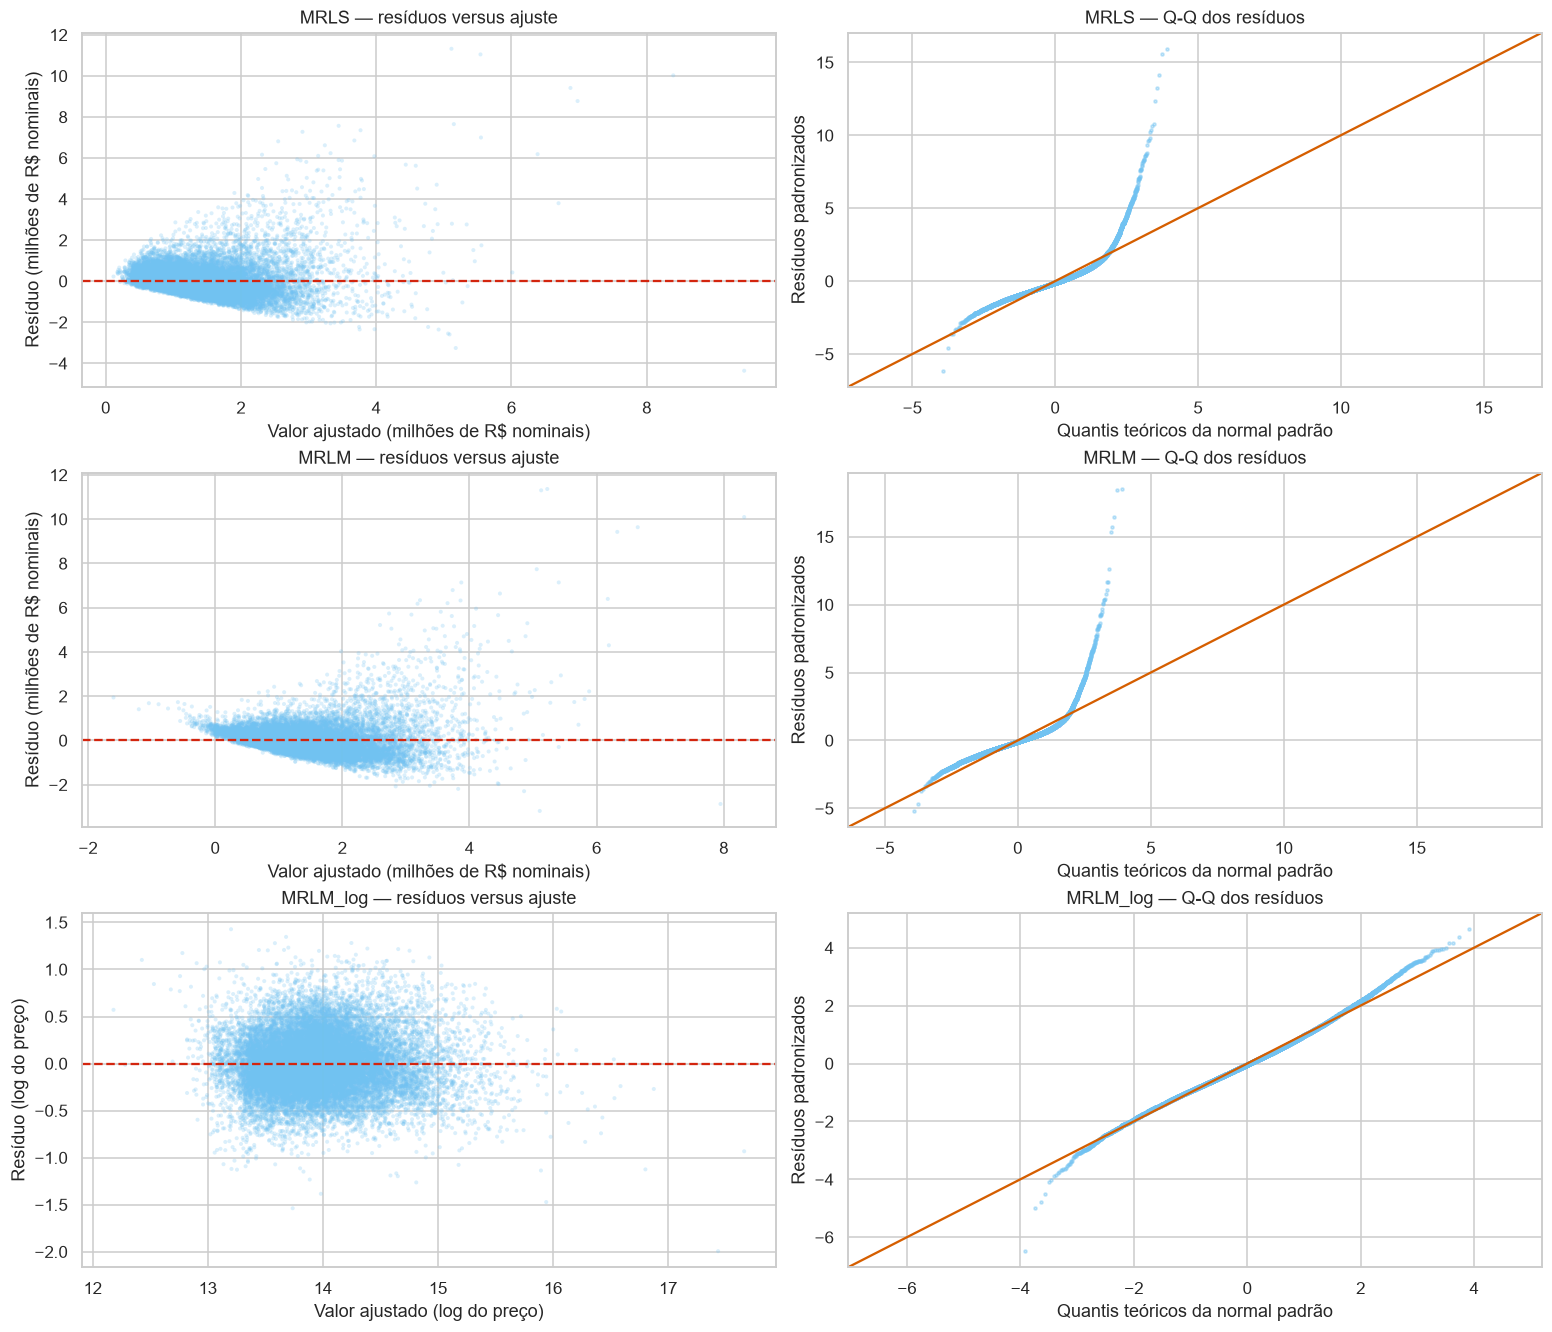

Os gráficos e testes devem ser considerados conjuntamente. Resíduos positivos mostram vendas acima do valor ajustado; não identificam, por si só, uma categoria de imóveis de luxo. A transformação logarítmica precisa ser avaliada pelos resíduos e não apenas pelo R² em outra escala. A inferência clássica não está validada por estes diagnósticos; heterocedasticidade e dependência entre revendas exigem avaliação de covariâncias e sensibilidade adequadas.

In [20]:
registros_diagnostico = []
fig, eixos = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
for linha, (nome, modelo) in enumerate(modelos_ajustados.items()):
    registros_diagnostico.append(avaliar_residuos(modelo, nome))
    divisor = 1 if nome == 'MRLM_log' else 1e6
    unidade_grafico = 'log do preço' if nome == 'MRLM_log' else 'milhões de R$ nominais'
    eixos[linha, 0].scatter(modelo.fittedvalues / divisor, modelo.resid / divisor,
                           s=7, alpha=0.25, color=AZUL, edgecolors='none')
    eixos[linha, 0].axhline(0, color=VERMELHO, linestyle='--', linewidth=1.5)
    eixos[linha, 0].set(xlabel=f'Valor ajustado ({unidade_grafico})',
                       ylabel=f'Resíduo ({unidade_grafico})', title=f'{nome} — resíduos versus ajuste')
    residuos_padronizados = modelo.resid / np.sqrt(modelo.mse_resid)
    sm.qqplot(residuos_padronizados, line='45', ax=eixos[linha, 1],
              markerfacecolor=AZUL, markeredgecolor=AZUL, alpha=0.4, markersize=2)
    eixos[linha, 1].set(xlabel='Quantis teóricos da normal padrão', ylabel='Resíduos padronizados',
                       title=f'{nome} — Q-Q dos resíduos')
diagnostico_residuos = pd.DataFrame(registros_diagnostico)
display(diagnostico_residuos)
salvar_tabela(diagnostico_residuos, 'diagnostico_residuos.csv')
salvar_grafico(fig, '06_diagnostico_residuos.png')
display(Markdown(
    'Os gráficos e testes devem ser considerados conjuntamente. Resíduos positivos mostram vendas '
    'acima do valor ajustado; não identificam, por si só, uma categoria de imóveis de luxo. '
    'A transformação logarítmica precisa ser avaliada pelos resíduos e não apenas pelo R² em outra escala. '
    'A inferência clássica não está validada por estes diagnósticos; heterocedasticidade e dependência '
    'entre revendas exigem avaliação de covariâncias e sensibilidade adequadas.'
))

## 15. Multicolinearidade — VIF

O VIF é calculado com a **matriz do MRLM que inclui intercepto**, mas a tabela apresenta somente as cinco explicativas. Os dois modelos múltiplos utilizam o mesmo desenho de preditoras e, portanto, apresentam os mesmos valores de VIF. A conversão fixa da área preserva esses fatores.

O valor 5 é adotado como referência de inspeção, sem representar um limite universal. Valores inferiores a esse limiar não garantem estabilidade estrutural dos coeficientes nem ausência de problemas de condicionamento numérico.

Referência: [fator de inflação da variância](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html).

In [21]:
matriz_modelo = modelo_multiplo.model.exog
nomes_modelo = modelo_multiplo.model.exog_names
vif_preditoras = pd.DataFrame([
    {'preditora': nome, 'vif': variance_inflation_factor(matriz_modelo, indice)}
    for indice, nome in enumerate(nomes_modelo) if nome != 'Intercept'
]).sort_values('vif', ascending=False).reset_index(drop=True)
display(vif_preditoras.assign(vif=vif_preditoras['vif'].map(lambda valor: formatar_valor(valor, 4))))
salvar_tabela(vif_preditoras, 'vif_preditoras.csv')
print('Posto da matriz do MRLM:', np.linalg.matrix_rank(matriz_modelo), 'de', matriz_modelo.shape[1], 'colunas')
display(Markdown(
    f'O maior VIF calculado foi **{formatar_valor(vif_preditoras["vif"].max(), 4)}**. '
    'A tabela permite avaliar cada explicativa; esse diagnóstico não demonstra estabilidade '
    'dos coeficientes nem substitui as demais verificações do modelo.'
))

,preditora,vif
0,area,"3,4691"
1,bathrooms,"2,8666"
2,grade,"2,7998"
3,yr_built,"1,5522"
4,lat,"1,0732"


Posto da matriz do MRLM: 6 de 6 colunas


O maior VIF calculado foi **3,4691**. A tabela permite avaliar cada explicativa; esse diagnóstico não demonstra estabilidade dos coeficientes nem substitui as demais verificações do modelo.

## 16. Observações sinalizadas no MRLM: resíduos, alavancagem e Cook

O diagnóstico utiliza o MRLM com resposta em reais nominais e os seguintes critérios:

- Resíduo studentizado **interno**: \(|r_i|>3\).
- Alavancagem: \(h_{ii}>2p/n\), com \(p\) incluindo o intercepto.
- Distância de Cook: \(D_i>4/n\).

O tamanho \(n\), o número de parâmetros e a identificação das vendas são obtidos do modelo efetivamente ajustado. Os critérios podem se sobrepor e servem para investigação, sem justificar exclusão automática.

O gráfico de Cook apresenta **todas as vendas**, identificadas pela linha original do CSV. A escala é linear nas proximidades de zero e logarítmica além do limiar, permitindo visualizar valores de diferentes ordens de grandeza sem retirar observações.

A tabela completa e a seleção sinalizada preservam `id`, data, preço e `linha_csv`, permitindo localizar os casos.

Referência: [diagnósticos de influência em MQO](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html).

,criterio,limiar,vendas,percentual,n_modelo,parametros
0,|residuo_estud| > 3,"3,00",325,"1,50",21613,6
1,alavancagem > 2p/n,"0,00055522",1259,"5,83",21613,6
2,Cook > 4/n,"0,00018507",1000,"4,63",21613,6


Vendas distintas sinalizadas por pelo menos um critério: 1784


,linha_csv,id,date,preco,residuo_estud,alavancagem,distancia_cook
7252,7254,6762700020,2014-10-13,"18.420.710,00","16,52","0,0080616","0,36977"
3914,3916,9808700762,2014-06-11,"15.754.318,75","15,41","0,0059076","0,23516"
9254,9256,9208900037,2014-09-19,"16.287.156,00","15,74","0,0041459","0,1719"
1448,1450,8907500070,2015-04-13,"16.590.885,00","18,54","0,0022288","0,128"
1315,1317,7558700030,2015-04-13,"16.435.830,00","18,44","0,0018453","0,10479"
4411,4413,2470100110,2014-08-04,"12.575.389,00","10,44","0,0031216","0,056908"
1164,1166,1247600105,2014-10-20,"12.549.058,32","11,65","0,0021974","0,049845"
12370,12372,6065300370,2015-05-06,"12.800.736,00","12,63","0,0018086","0,048143"
12777,12779,1225069038,2014-05-05,"5.081.208,00","-4,70","0,011097","0,041353"
8092,8094,1924059029,2014-06-17,"10.496.464,80","7,02","0,0040268","0,03325"


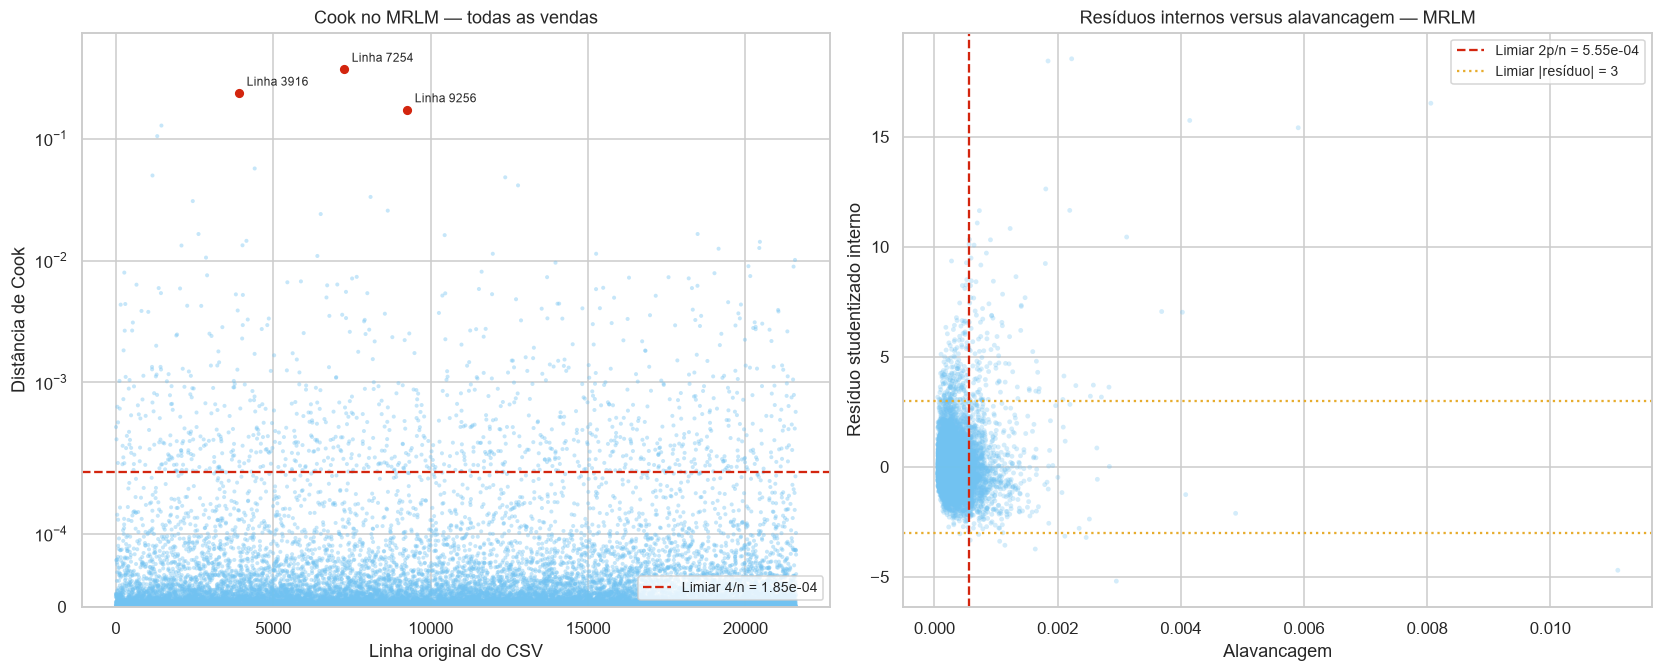

Foram sinalizadas **325 vendas** por resíduo interno, **1.259** por alavancagem e **1.000** por Cook. As contagens se sobrepõem. Nenhuma dessas vendas foi retirada automaticamente.

O maior Cook foi **0,36977**, na **linha 7254** do CSV, ID `6762700020`. Esse caso deve ser examinado junto das características e da rastreabilidade do registro, sem concluir erro cadastral ou necessidade de exclusão apenas pelo limiar.

In [22]:
def avaliar_influencia(modelo, base):
    linhas_modelo = pd.Index(modelo.model.data.row_labels)
    origem = base.loc[linhas_modelo]
    influencia = modelo.get_influence()
    n_vendas, n_parametros = int(modelo.nobs), len(modelo.params)
    limiar_alavanca, limiar_cook = 2 * n_parametros / n_vendas, 4 / n_vendas
    diagnostico = origem[['linha_csv', 'id', 'date', 'preco', 'area']].copy()
    diagnostico['preco_estimado'] = modelo.fittedvalues
    diagnostico['residuo'] = modelo.resid
    diagnostico['residuo_estud'] = influencia.resid_studentized_internal
    diagnostico['alavancagem'] = influencia.hat_matrix_diag
    diagnostico['distancia_cook'] = influencia.cooks_distance[0]
    diagnostico['sinal_residuo'] = diagnostico['residuo_estud'].abs() > 3
    diagnostico['sinal_alavanca'] = diagnostico['alavancagem'] > limiar_alavanca
    diagnostico['sinal_cook'] = diagnostico['distancia_cook'] > limiar_cook
    diagnostico['sinalizado'] = diagnostico[['sinal_residuo', 'sinal_alavanca', 'sinal_cook']].any(axis=1)
    resumo = pd.DataFrame([
        {'criterio': criterio, 'limiar': limiar, 'vendas': int(diagnostico[sinal].sum()),
         'percentual': 100 * diagnostico[sinal].mean(), 'n_modelo': n_vendas, 'parametros': n_parametros}
        for criterio, sinal, limiar in [
            ('|residuo_estud| > 3', 'sinal_residuo', 3),
            ('alavancagem > 2p/n', 'sinal_alavanca', limiar_alavanca),
            ('Cook > 4/n', 'sinal_cook', limiar_cook)
        ]
    ])
    return diagnostico, resumo

diagnostico_vendas, diagnostico_atipicos = avaliar_influencia(modelo_multiplo, base_ajustada)
observacoes_sinalizadas = diagnostico_vendas.loc[diagnostico_vendas['sinalizado']].sort_values('distancia_cook', ascending=False)
display(diagnostico_atipicos)
print('Vendas distintas sinalizadas por pelo menos um critério:', len(observacoes_sinalizadas))
display(observacoes_sinalizadas[['linha_csv', 'id', 'date', 'preco', 'residuo_estud', 'alavancagem', 'distancia_cook']].head(10))
salvar_tabela(diagnostico_vendas, 'diagnostico_vendas.csv')
salvar_tabela(diagnostico_atipicos, 'diagnostico_atipicos.csv')
salvar_tabela(observacoes_sinalizadas, 'observacoes_sinalizadas.csv')

limiar_alavanca = 2 * len(modelo_multiplo.params) / modelo_multiplo.nobs
limiar_cook = 4 / modelo_multiplo.nobs
fig, eixos = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
eixos[0].scatter(diagnostico_vendas['linha_csv'], diagnostico_vendas['distancia_cook'],
                 s=7, alpha=0.4, color=AZUL, edgecolors='none')
eixos[0].axhline(limiar_cook, color=VERMELHO, linestyle='--', label=f'Limiar 4/n = {limiar_cook:.2e}')
eixos[0].set_yscale('symlog', linthresh=limiar_cook)
eixos[0].set_ylim(bottom=0, top=diagnostico_vendas['distancia_cook'].max() * 2)
eixos[0].set(xlabel='Linha original do CSV', ylabel='Distância de Cook',
             title='Cook no MRLM — todas as vendas')
for _, caso in diagnostico_vendas.nlargest(3, 'distancia_cook').iterrows():
    eixos[0].scatter(caso['linha_csv'], caso['distancia_cook'], s=25, color=VERMELHO)
    eixos[0].annotate(f'Linha {int(caso["linha_csv"])}',
                     (caso['linha_csv'], caso['distancia_cook']), xytext=(5, 5),
                     textcoords='offset points', fontsize=8)
eixos[0].legend(loc='lower right', fontsize=9)
eixos[1].scatter(diagnostico_vendas['alavancagem'], diagnostico_vendas['residuo_estud'],
                 s=10, alpha=0.3, color=AZUL, edgecolors='none')
eixos[1].axvline(limiar_alavanca, color=VERMELHO, linestyle='--', label=f'Limiar 2p/n = {limiar_alavanca:.2e}')
eixos[1].axhline(3, color=LARANJA, linestyle=':', label='Limiar |resíduo| = 3')
eixos[1].axhline(-3, color=LARANJA, linestyle=':')
eixos[1].set(xlabel='Alavancagem', ylabel='Resíduo studentizado interno',
             title='Resíduos internos versus alavancagem — MRLM')
eixos[1].legend(fontsize=9)
salvar_grafico(fig, '05_diagnostico_atipicos.png')
maior_cook = diagnostico_vendas.loc[diagnostico_vendas['distancia_cook'].idxmax()]
display(Markdown(
    f'Foram sinalizadas **{formatar_valor(diagnostico_atipicos.iloc[0]["vendas"], 0)} vendas** por resíduo interno, '
    f'**{formatar_valor(diagnostico_atipicos.iloc[1]["vendas"], 0)}** por alavancagem e '
    f'**{formatar_valor(diagnostico_atipicos.iloc[2]["vendas"], 0)}** por Cook. '
    'As contagens se sobrepõem. Nenhuma dessas vendas foi retirada automaticamente.\n\n'
    f'O maior Cook foi **{formatar_valor(maior_cook["distancia_cook"], 5)}**, '
    f'na **linha {int(maior_cook["linha_csv"])}** do CSV, ID `{maior_cook["id"]}`. '
    'Esse caso deve ser examinado junto das características e da rastreabilidade do registro, '
    'sem concluir erro cadastral ou necessidade de exclusão apenas pelo limiar.'
))

## 17. Síntese da análise integrada

A análise integra auditoria, conversões rastreáveis e preservação das revendas com três especificações de regressão. A interpretação reúne coeficientes, medidas do ajuste e diagnósticos de resíduos, multicolinearidade e influência.

O MRLM descreve associações condicionais às cinco explicativas incluídas, mas permanece sujeito a fatores não observados e às limitações da base observacional. O modelo em log deve ser interpretado em sua própria escala; seu R² não é diretamente comparável ao dos modelos em reais.

A inferência permanece clássica. A avaliação de covariâncias adequadas à heterocedasticidade e à dependência entre revendas, análises de sensibilidade e validação preditiva fora da amostra constituem etapas futuras. Os resultados atuais descrevem a amostra e não estabelecem desempenho para novos imóveis ou vendas futuras.

In [23]:
diagnostico_log = diagnostico_residuos.set_index('modelo').loc['MRLM_log']
display(Markdown(
    f'Os três modelos utilizaram **{formatar_valor(len(base_ajustada), 0)} vendas**. '
    f'O MRLM em reais apresentou R² = **{formatar_valor(modelo_multiplo.rsquared, 5)}** '
    f'e erro padrão residual de **R$ {formatar_valor(np.sqrt(modelo_multiplo.mse_resid))}**. '
    f'O MRLM log apresentou R² = **{formatar_valor(modelo_log.rsquared, 5)}**, em escala logarítmica.\n\n'
    f'No modelo log, JB = **{formatar_valor(diagnostico_log["jarque_bera"])}**, '
    f'p {diagnostico_log["valor_p_jb"]}; BP/Koenker = '
    f'**{formatar_valor(diagnostico_log["breusch_pagan_koenker"])}**, p {diagnostico_log["valor_p_bp"]}. '
    'Esses resultados, junto dos gráficos, não sustentam afirmar que a transformação '
    'tenha resolvido todos os pressupostos. As conclusões ficam restritas à amostra '
    'observacional e às especificações estudadas.'
))

Os três modelos utilizaram **21.613 vendas**. O MRLM em reais apresentou R² = **0,59183** e erro padrão residual de **R$ 613.642,46**. O MRLM log apresentou R² = **0,67761**, em escala logarítmica.

No modelo log, JB = **547,69**, p < 0,001; BP/Koenker = **470,22**, p < 0,001. Esses resultados, junto dos gráficos, não sustentam afirmar que a transformação tenha resolvido todos os pressupostos. As conclusões ficam restritas à amostra observacional e às especificações estudadas.